# Data Cleaning for Main Dataset (PCOS data without infertility)
This section consists of data cleaning and preprocessing of the main PCOS dataset. The steps conducted are:
1. Mount drive, load and inspect Excel file
2. Standardise column names
3. Remove any header/title rows and any duplicate rows
4. Convert columns to numeric where expected
*   The values in these numeric columns are cleaned by removing non-numeric/non-period characters and trailing dots.
5. Clean binary columns by standardising values to 1 or 0
*   For cycle_r_i, 4 (Irregular) and 2 (Regular) are used instead of 1 and 0. To standardise, it is changed to 1 (Irregular) and 0 (Regular) since 1 is usually the positive class to observe for anomaly while 0 is usually used as the reference/baseline category in statistics.
6. Fix categorical codes
7. Identify potential outliers using the Interquartile Range (IQR) method to determine which outliers to remove
8. Replace impossible outliers with NaN
*   Through inspecting outlier values, biologically impossible values, which are out of bounds, are replaced with NaN, marking them as missing values.
9. Handle missing values
*   To ensure reliability of dataset, all rows with any NaN values are removed.
10. Quality check on derived columns (Body Mass Index (BMI), Waist-Hip Ratio) to ensure integrity and accuracy of these calculated columns
11. Enforce final column types (numeric, binary, categorical)
12. Final quality check (missing values, duplicate rows) and save csv file

Note: `errors='coerce'` argument is used in many parts of the code, as it tells Python to replace any values that cannot be converted into a number with NaN (Not a Number). This is a soft treatment for unwanted values and can be dealt with later (removed in this case).

In [1]:
### mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
### load and inspect Excel file
import pandas as pd
import numpy as np

path = "/content/drive/MyDrive/HerGenome_(Main_Dataset)_PCOS_data_without_infertility.xlsx"
xl = pd.ExcelFile(path)
print(xl.sheet_names)

df = pd.read_excel(path, sheet_name="Full_new")
print(df.shape)
print(df.columns.tolist())
print(df.head(5))
print(df.info())

['Instructions', 'Full_new']
(541, 44)
['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']
   Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  Height(Cm)   \
0       1                 1           0          28         44.6        152.0   
1       2         

In [3]:
### standardise column names
import re

def clean_col(c):
    c = str(c).strip()                    # convert input to string, remove whitespace
    c = re.sub(r'[^A-Za-z0-9]+', '_', c)  # replace non-alphanumeric characters with '_'
    c = re.sub(r'_+', '_', c)             # consolidate multiple '_' into a single one
    return c.strip('_').lower()           # remove any leading/trailing '_', convert entire name to lowercase

df.columns = [clean_col(c) for c in df.columns]
print(df.columns.tolist())

['sl_no', 'patient_file_no', 'pcos_y_n', 'age_yrs', 'weight_kg', 'height_cm', 'bmi', 'blood_group', 'pulse_rate_bpm', 'rr_breaths_min', 'hb_g_dl', 'cycle_r_i', 'cycle_length_days', 'marraige_status_yrs', 'pregnant_y_n', 'no_of_abortions', 'i_beta_hcg_miu_ml', 'ii_beta_hcg_miu_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh', 'hip_inch', 'waist_inch', 'waist_hip_ratio', 'tsh_miu_l', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'rbs_mg_dl', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']


In [4]:
### remove repeated header/title rows
## identify rows where many cells contain header text or "TITLE"
row_text = df.astype(str).apply(lambda row: " ".join(row.values), axis=1).str.lower()
mask_repeated_header = row_text.str.contains(r'\btitle\b') | row_text.str.contains(r'sl\.?\s*no')

df = df.loc[~mask_repeated_header].copy()  # remove these rows

## reset row index and drop full-row duplicates
df = df.reset_index(drop=True)
df = df.drop_duplicates()

print(df.shape)

(541, 44)


In [5]:
### convert columns to numeric where expected
numeric_cols = [
    'sl_no', 'patient_file_no', 'age_yrs', 'weight_kg', 'height_cm', 'bmi',
    'pulse_rate_bpm', 'rr_breaths_min', 'hb_g_dl', 'cycle_length_days',
    'marraige_status_yrs', 'no_of_abortions', 'i_beta_hcg_miu_ml',
    'ii_beta_hcg_miu_ml', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh', 'hip_inch', 'waist_inch',
    'waist_hip_ratio', 'tsh_miu_l', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml',
    'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'follicle_no_l',
    'follicle_no_r', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm'
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = (df[c].astype(str)                         # convert to string
                 .str.replace(r'[^0-9\.]', '', regex=True) # remove non-numeric/non-period characters
                 .str.replace(r'\.$', '', regex=True)      # remove trailing dots
                )
        df[c] = pd.to_numeric(df[c], errors='coerce')  # convert cleaned values to numeric type
        print(df[c].dtypes)


int64
int64
int64
float64
float64
float64
int64
int64
float64
int64
float64
int64
float64
float64
float64
float64
float64
int64
int64
float64
float64
float64
float64
float64
float64
float64
int64
int64
int64
int64
float64
float64
float64


In [6]:
### clean binary columns
binary_cols = [
    'pcos_y_n', 'cycle_r_i', 'pregnant_y_n', 'weight_gain_y_n',
    'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n',
    'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n'
]

## standardise values to 1 or 0
mapping = {
    '1': 1, 1: 1, True: 1, '1.0': 1, 1.0: 1, 4: 1, '4': 1, 4.0: 1, '4.0': 1,
    '0': 0, 0: 0, False: 0, '0.0': 0, 0.0: 0, 2: 0, '2': 0, 2.0: 0, '2.0': 0,
     # for cycle_r_i, Irregular = 4 = 1, Regular = 2 = 0
}

for c in binary_cols:
    if c in df.columns:
        # convert to string, remove whitespace, convert to lowercase, apply mapping
        df[c] = df[c].astype(str).str.strip().str.lower().map(mapping)

## check if each column is binary (only 0 and 1, allowing NaN) after cleaning
binary_check = {
    col_name: set(df[col_name].dropna().unique()) == {0, 1}
    for col_name in binary_cols if col_name in df.columns
}

print(binary_check)

{'pcos_y_n': True, 'cycle_r_i': True, 'pregnant_y_n': True, 'weight_gain_y_n': True, 'hair_growth_y_n': True, 'skin_darkening_y_n': True, 'hair_loss_y_n': True, 'pimples_y_n': True, 'fast_food_y_n': True, 'reg_exercise_y_n': True}


In [7]:
### fix categorical codes
if 'blood_group' in df.columns:
    # convert to numeric type, replace any values that cannot be converted into a no. with NaN
    df['blood_group'] = pd.to_numeric(df['blood_group'], errors='coerce')
    print(df['blood_group'].dtypes)

int64


In [8]:
### identify potential outliers using IQR
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return lo, hi

outlier_details = {}
for c in numeric_cols:
    if c in df.columns:
        series_clean = df[c].dropna()
        if not series_clean.empty:  # ensure series is not empty after dropping NaN
            lo, hi = iqr_outliers(series_clean)  # calculate bounds
            outlier_mask = (df[c] < lo) | (df[c] > hi)
            num_outliers = outlier_mask.sum()    # outlier count

            if num_outliers > 0:
                outlier_details[c] = {
                    'lower_bound': lo,
                    'upper_bound': hi,
                    'num_outliers': int(num_outliers),
                    'outlier_values': df[c][outlier_mask].tolist() # store actual outlier values
                }

## summary of outliers (bounds, outlier count, and actual values)
for col, details in outlier_details.items():
    print(f"\nColumn: {col}")
    print(f"  Usual Range (IQR bounds): [{details['lower_bound']:.2f}, {details['upper_bound']:.2f}]")
    print(f"  No. of Outliers: {details['num_outliers']}")
    print(f"  Outlier Values: {details['outlier_values']}")


Column: age_yrs
  Usual Range (IQR bounds): [17.50, 45.50]
  No. of Outliers: 5
  Outlier Values: [47, 47, 47, 48, 46]

Column: weight_kg
  Usual Range (IQR bounds): [32.50, 84.50]
  No. of Outliers: 18
  Outlier Values: [85.0, 108.0, 91.4, 89.0, 85.0, 89.0, 88.0, 31.0, 104.0, 85.0, 32.0, 32.0, 85.0, 89.0, 85.0, 89.0, 94.0, 87.9]

Column: height_cm
  Usual Range (IQR bounds): [140.00, 172.00]
  No. of Outliers: 6
  Outlier Values: [137.0, 180.0, 173.0, 173.0, 173.7, 173.0]

Column: bmi
  Usual Range (IQR bounds): [14.31, 34.04]
  No. of Outliers: 13
  Outlier Values: [13.38796706, 35.69716021, 38.26530612, 38.5393827, 12.41788175, 38.47952593, 36.31082062, 13.49300051, 14.283241, 13.85041551, 34.3350951, 38.90071431, 35.21070341]

Column: pulse_rate_bpm
  Usual Range (IQR bounds): [69.00, 77.00]
  No. of Outliers: 94
  Outlier Values: [78, 78, 80, 80, 78, 80, 80, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 80, 78, 78, 80, 80, 80, 80, 78, 80, 78, 78, 80, 78, 78, 78, 78, 78, 80, 78, 78, 78,

In [9]:
### fix impossible values
rules = {
    'pulse_rate_bpm': (60, 100),    # resting heart rate range for healthy adults
    'fsh_miu_ml': (-2, 70),         # within possible range of fsh levels
    'lh_miu_ml': (-3, 50),          # within possible range of lh levels
    'vit_d3_ng_ml': (0, 100),       # within possible range of vit D3
    'bp_systolic_mmhg': (90, 200),  # possible systolic blood pressure range
    'bp_diastolic_mmhg': (50, 140), # possible diastolic blood pressure range
}

for c, (lo, hi) in rules.items():
    if c in df.columns:
        # replace values outside the defined lower and upper bounds with NaN, mark as missing data
        df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan

In [10]:
### handle missing values
## inspect missing values
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

## remove all rows with any NaN values
df.dropna(inplace=True)
print(df.shape)

pulse_rate_bpm         2
vit_d3_ng_ml           2
marraige_status_yrs    1
cycle_r_i              1
fast_food_y_n          1
bp_systolic_mmhg       1
bp_diastolic_mmhg      1
amh_ng_ml              1
lh_miu_ml              1
fsh_miu_ml             1
dtype: int64
(529, 44)


In [11]:
### quality check on derived columns (for verification only, no new columns saved)
## bmi column
if {'weight_kg', 'height_cm', 'bmi'}.issubset(df.columns):
    temp_bmi_calc = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)  # recalculate bmi

    # compare with existing 'bmi' where both are not NaN
    common_index_bmi = df[['bmi', 'weight_kg', 'height_cm']].dropna().index

    if not common_index_bmi.empty:
        bmi_exist = df.loc[common_index_bmi, 'bmi']  # use .loc to ensure alignment and consider only rows with complete data for comparison
        bmi_recalc = temp_bmi_calc.loc[common_index_bmi]
        bmi_diff = (bmi_exist - bmi_recalc).abs()  # calculate absolute difference

        print(f"  Rows compared: {len(bmi_diff)}")
        print(f"  Mean absolute difference between existing BMI and re-calculated: {bmi_diff.mean():.6e}")
        print(f"  Max absolute difference between existing BMI and re-calculated: {bmi_diff.max():.6e}")

        # identify and print a sample of larger discrepancies if any
        threshold = 1e-4
        sig_discrepancies = bmi_diff[bmi_diff > threshold]
        if not sig_discrepancies.empty:
            print(f"  Found {len(sig_discrepancies)} rows with absolute BMI difference > {threshold}:")
            print(df.loc[sig_discrepancies.index, ['weight_kg', 'height_cm', 'bmi']].head())
        else:
            print(f"  No significant BMI discrepancies found (difference > {threshold}).")
    else:
        print("\nBMI Calculation Check: Not enough complete data (weight_kg, height_cm, bmi) to perform comparison.")
else:
    print("\nBMI Calculation Check: Required columns (weight_kg, height_cm, or bmi) are missing for comparison.")

## waist_hip_ratio column
if {'waist_inch', 'hip_inch', 'waist_hip_ratio'}.issubset(df.columns):
    temp_waist_hip_ratio_calc = df['waist_inch'] / df['hip_inch']  # recalculate waist-hip ratio

    # compare with existing 'waist_hip_ratio' where both are not NaN
    common_index_whr = df[['waist_hip_ratio', 'waist_inch', 'hip_inch']].dropna().index

    if not common_index_whr.empty:
        whr_exist = df.loc[common_index_whr, 'waist_hip_ratio']  # use .loc to ensure alignment and consider only rows with complete data for comparison
        whr_recalc = temp_waist_hip_ratio_calc.loc[common_index_whr]
        waist_hip_ratio_diff = (whr_exist - whr_recalc).abs()  # calculate absolute difference

        print(f"  Rows compared: {len(waist_hip_ratio_diff)}")
        print(f"  Mean absolute difference between existing Waist-Hip Ratio and re-calculated: {waist_hip_ratio_diff.mean():.6e}")
        print(f"  Max absolute difference between existing Waist-Hip Ratio and re-calculated: {waist_hip_ratio_diff.max():.6e}")

        # identify and print a sample of larger discrepancies if any
        threshold = 1e-4
        sig_discrepancies_whr = waist_hip_ratio_diff[waist_hip_ratio_diff > threshold]
        if not sig_discrepancies_whr.empty:
            print(f"  Found {len(sig_discrepancies_whr)} rows with absolute Waist-Hip Ratio difference > {threshold}:")
            print(df.loc[sig_discrepancies_whr.index, ['waist_inch', 'hip_inch', 'waist_hip_ratio']].head())
        else:
            print(f"  No significant Waist-Hip Ratio discrepancies found (difference > {threshold}).")
    else:
        print("\nWaist-Hip Ratio Calculation Check: Not enough complete data (waist_inch, hip_inch, waist_hip_ratio) to perform comparison.")
else:
    print("\nWaist-Hip Ratio Calculation Check: Required columns (waist_inch, hip_inch, or waist_hip_ratio) are missing for comparison.")

  Rows compared: 529
  Mean absolute difference between existing BMI and re-calculated: 2.394759e-09
  Max absolute difference between existing BMI and re-calculated: 4.991183e-09
  No significant BMI discrepancies found (difference > 0.0001).
  Rows compared: 529
  Mean absolute difference between existing Waist-Hip Ratio and re-calculated: 2.269778e-11
  Max absolute difference between existing Waist-Hip Ratio and re-calculated: 4.782608e-11
  No significant Waist-Hip Ratio discrepancies found (difference > 0.0001).


In [12]:
### enforce final column types
## numeric columns
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        print(df[c].dtypes)

## binary columns
for c in binary_cols:
    if c in df.columns:
        df[c] = df[c].round().astype('Int64')
        print(df[c].dtypes)

## categorical column
for c in ['blood_group']:
    if c in df.columns:
        df[c] = df[c].astype('Int64')
        print(df[c].dtypes)

int64
int64
int64
float64
float64
float64
float64
int64
float64
int64
float64
int64
float64
float64
float64
float64
float64
int64
int64
float64
float64
float64
float64
float64
float64
float64
float64
float64
int64
int64
float64
float64
float64
Int64
Int64
Int64
Int64
Int64
Int64
Int64
Int64
Int64
Int64
Int64


In [13]:
### final quality check
print(df.isna().sum().sort_values(ascending=False).head(10))  # check for any missing values (NaN)
print(df.duplicated().sum())  # check for any duplicate rows
print(df.describe(include='all').transpose())  # statistical summary

## save to csv
df.to_csv("cleaned_pcos_dataset.csv", index=False)

sl_no              0
patient_file_no    0
pcos_y_n           0
age_yrs            0
weight_kg          0
height_cm          0
bmi                0
blood_group        0
pulse_rate_bpm     0
rr_breaths_min     0
dtype: int64
0
                     count        mean          std        min       25%  \
sl_no                529.0  270.544423   157.017136        1.0     133.0   
patient_file_no      529.0  270.544423   157.017136        1.0     133.0   
pcos_y_n             529.0    0.325142     0.468871        0.0       0.0   
age_yrs              529.0   31.431002     5.434829       20.0      27.0   
weight_kg            529.0    59.65879    11.090953       31.0      52.0   
height_cm            529.0  156.430805     6.015008      137.0     152.0   
bmi                  529.0   24.344222     4.076082  12.417882    21.875   
blood_group          529.0   13.801512     1.847479       11.0      13.0   
pulse_rate_bpm       529.0   73.478261     2.705914       70.0      72.0   
rr_breaths_min 

# Exploratory Data Analysis (EDA)
This section consists of different types of data analysis, for better visualisation of data and aid in model building. The steps conducted are:
Preprocessing:
1. Load data
2. Separate feature types into numeric, binary and categorical

Feature distribution:

3. Target class balance (`pcos_y_n`)
4. Numeric feature distribution using histograms
5. Boxplots for outlier detection
6. Skewness check and inspect the top most skewed variables
7. Binary and categorical feature counts

Data analysis:

8. Correlation heatmap
9. Correlation with target only and a bar plot of top positive and negative associations
10. Feature-vs-target comparisons
11. Compare feature distribution by PCOS status


In [14]:
### load data
df = pd.read_csv("cleaned_pcos_dataset.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(10))

(529, 44)
   sl_no  patient_file_no  pcos_y_n  age_yrs  weight_kg  height_cm        bmi  \
0      1                1         0       28       44.6      152.0  19.304017   
1      2                2         0       36       65.0      161.5  24.921163   
2      3                3         1       33       68.8      165.0  25.270891   
3      4                4         0       37       65.0      148.0  29.674945   
4      5                5         0       25       52.0      161.0  20.060954   

   blood_group  pulse_rate_bpm  rr_breaths_min  ...  pimples_y_n  \
0           15            78.0              22  ...            0   
1           15            74.0              20  ...            0   
2           11            72.0              18  ...            1   
3           13            72.0              20  ...            0   
4           11            72.0              18  ...            0   

   fast_food_y_n  reg_exercise_y_n  bp_systolic_mmhg  bp_diastolic_mmhg  \
0              1   

In [15]:
### separate feature types
target = "pcos_y_n"

## columns that are clearly identifiers and usually not useful for EDA modeling
id_cols = ["sl_no", "patient_file_no"]

## numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

## exclude identifiers from most plots
num_eda_cols = [c for c in num_cols if c not in id_cols]

## binary/categorical-like columns in this dataset
binary_cols = [
    "pcos_y_n", 'cycle_r_i', "pregnant_y_n", "weight_gain_y_n", "hair_growth_y_n",
    "skin_darkening_y_n", "hair_loss_y_n", "pimples_y_n",
    "fast_food_y_n", "reg_exercise_y_n"
]

cat_cols = [c for c in ["blood_group"] if c in df.columns]

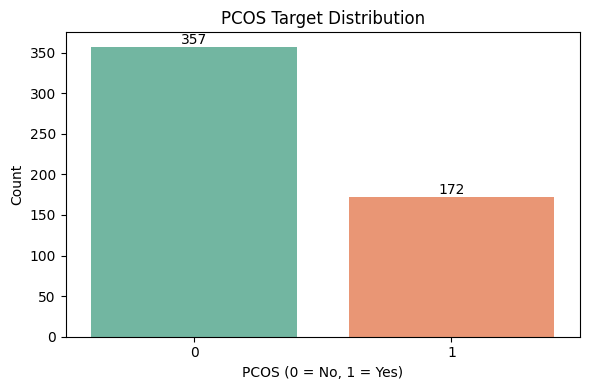

pcos_y_n
0    357
1    172
Name: count, dtype: int64
pcos_y_n
0    0.675
1    0.325
Name: proportion, dtype: float64


In [16]:
### target class balance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x=target, palette="Set2", hue=target, legend=False)
plt.title("PCOS Target Distribution")
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(df[target].value_counts())
print(df[target].value_counts(normalize=True).round(3))

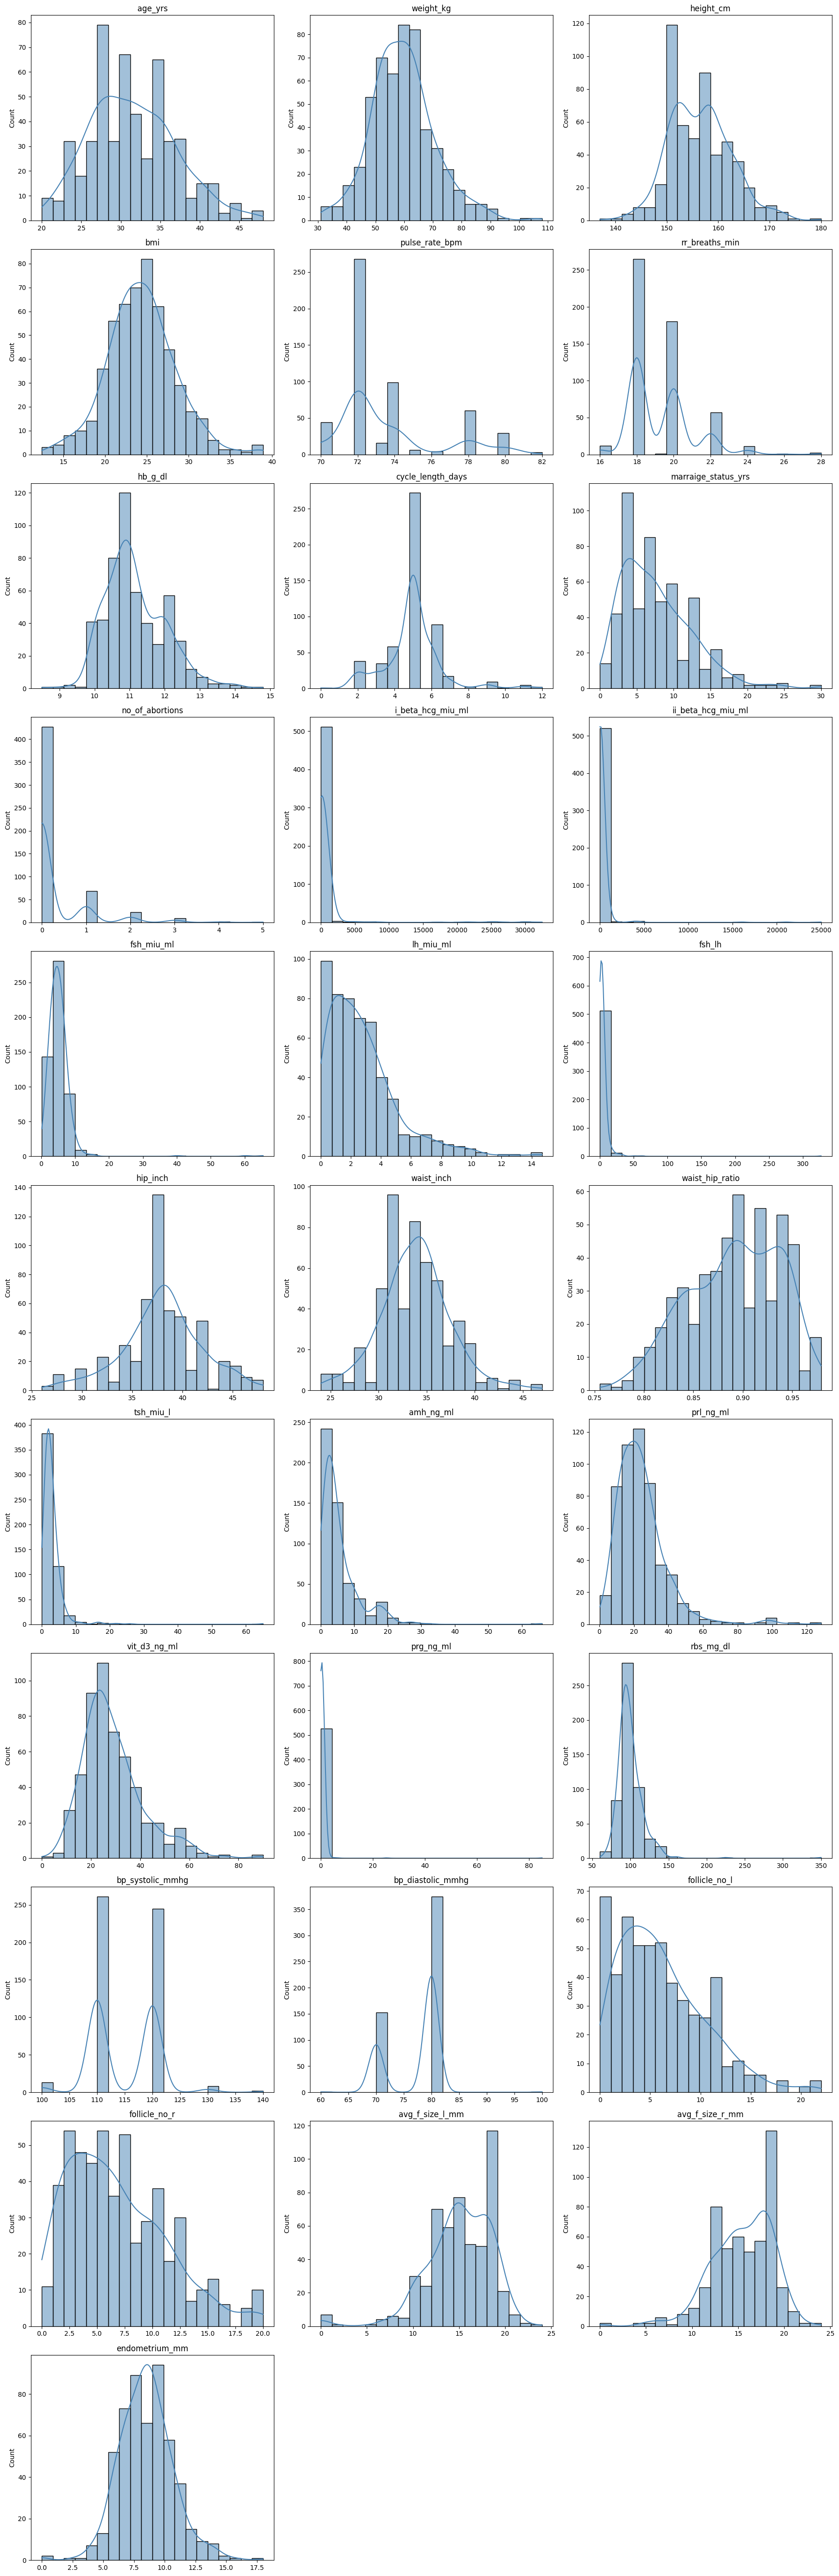

In [17]:
### numeric feature distributions (histogram)
import math
import matplotlib.pyplot as plt
import seaborn as sns

plot_cols = [c for c in num_eda_cols if c not in binary_cols and c not in cat_cols and c != target]

ncols = 3
nrows = math.ceil(len(plot_cols) / ncols)

plt.figure(figsize=(18, 5 * nrows))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(df[col], kde=True, bins=20, color="steelblue")
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.show()

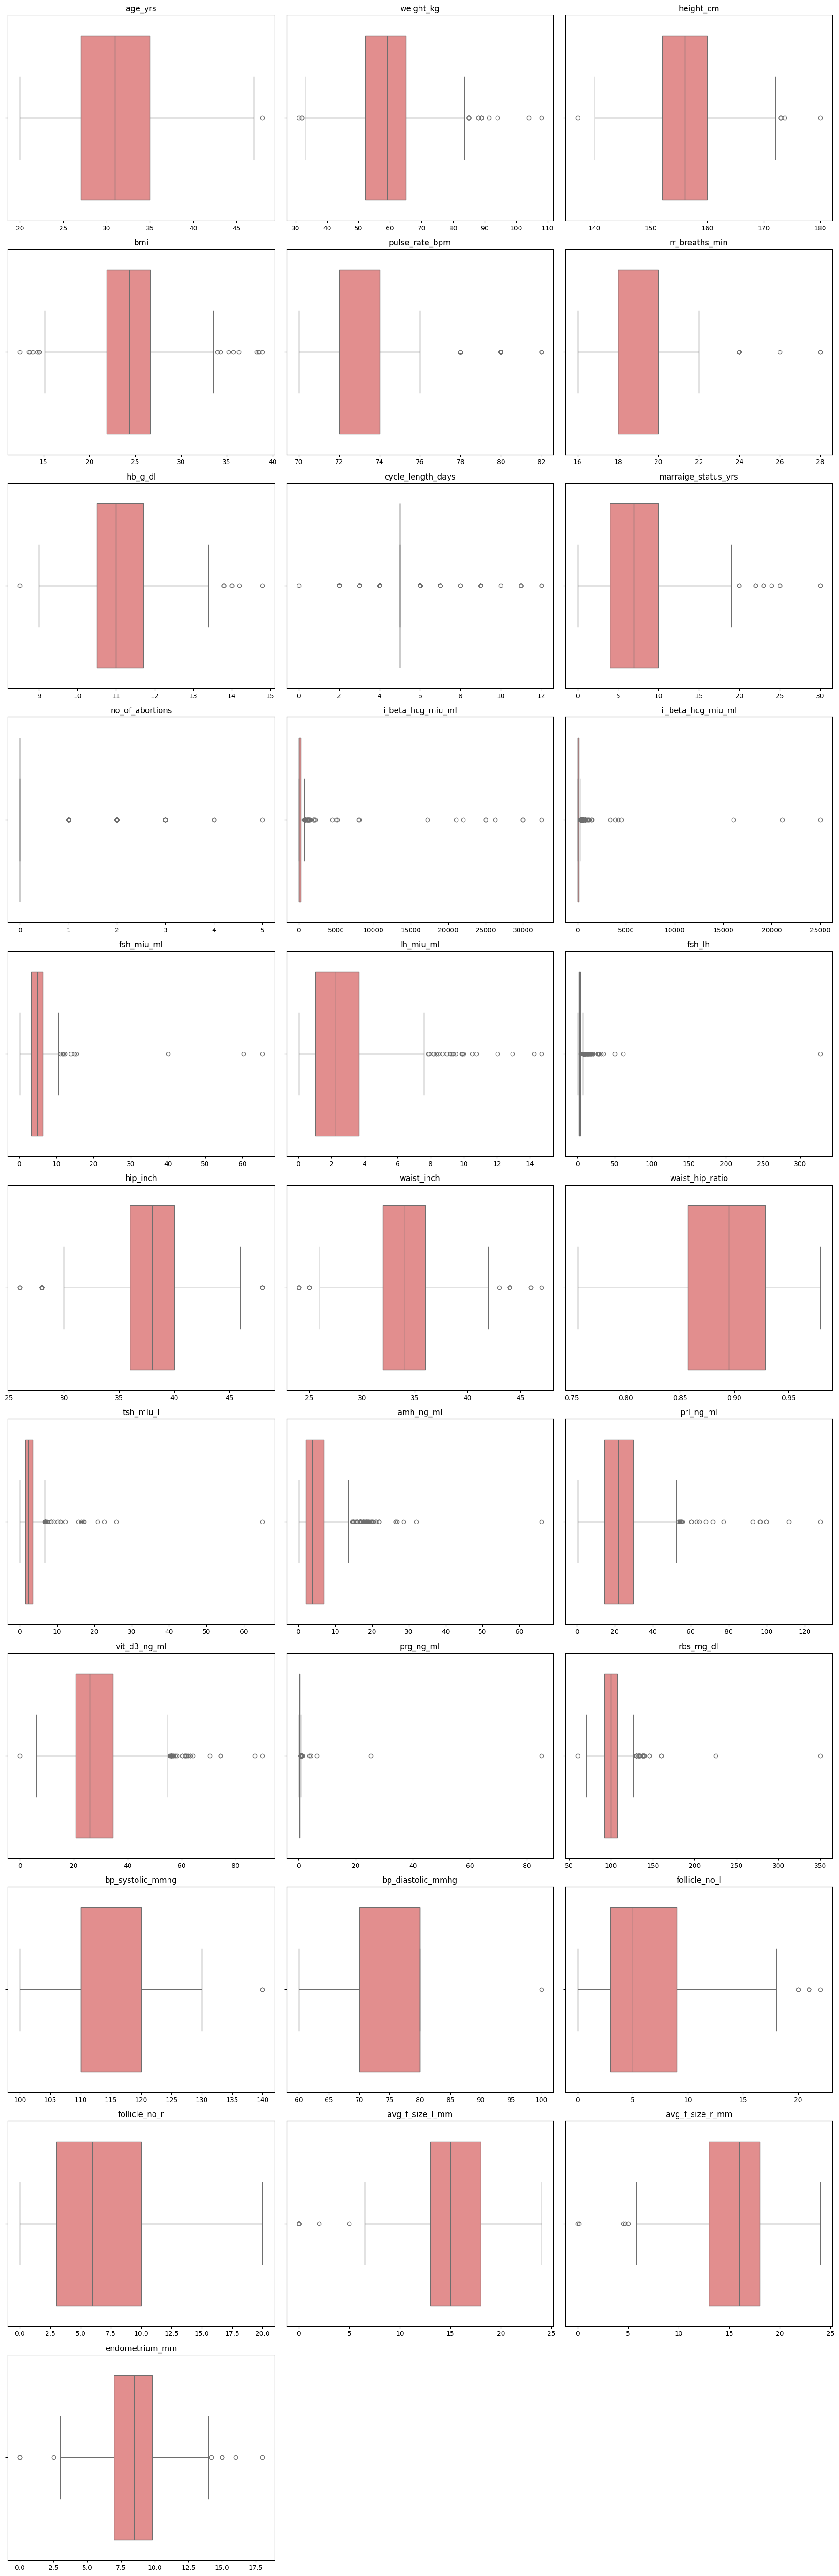

In [18]:
### boxplots for outlier detection
plt.figure(figsize=(18, 5 * nrows))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.show()

prg_ng_ml              20.500141
fsh_lh                 18.915790
ii_beta_hcg_miu_ml     12.674514
tsh_miu_l               9.976212
fsh_miu_ml              9.185124
i_beta_hcg_miu_ml       7.437216
rbs_mg_dl               5.462912
amh_ng_ml               3.284289
no_of_abortions         2.979853
prl_ng_ml               2.449680
lh_miu_ml               1.660424
rr_breaths_min          1.236688
pulse_rate_bpm          1.230940
vit_d3_ng_ml            1.224132
marraige_status_yrs     1.158413
follicle_no_l           0.951557
cycle_length_days       0.836279
follicle_no_r           0.782052
hb_g_dl                 0.757418
weight_kg               0.513136
age_yrs                 0.358626
height_cm               0.320158
endometrium_mm          0.256752
bmi                     0.256378
bp_systolic_mmhg        0.213218
waist_inch              0.192560
hip_inch               -0.205153
waist_hip_ratio        -0.339531
bp_diastolic_mmhg      -0.711298
avg_f_size_r_mm        -0.805768
avg_f_size

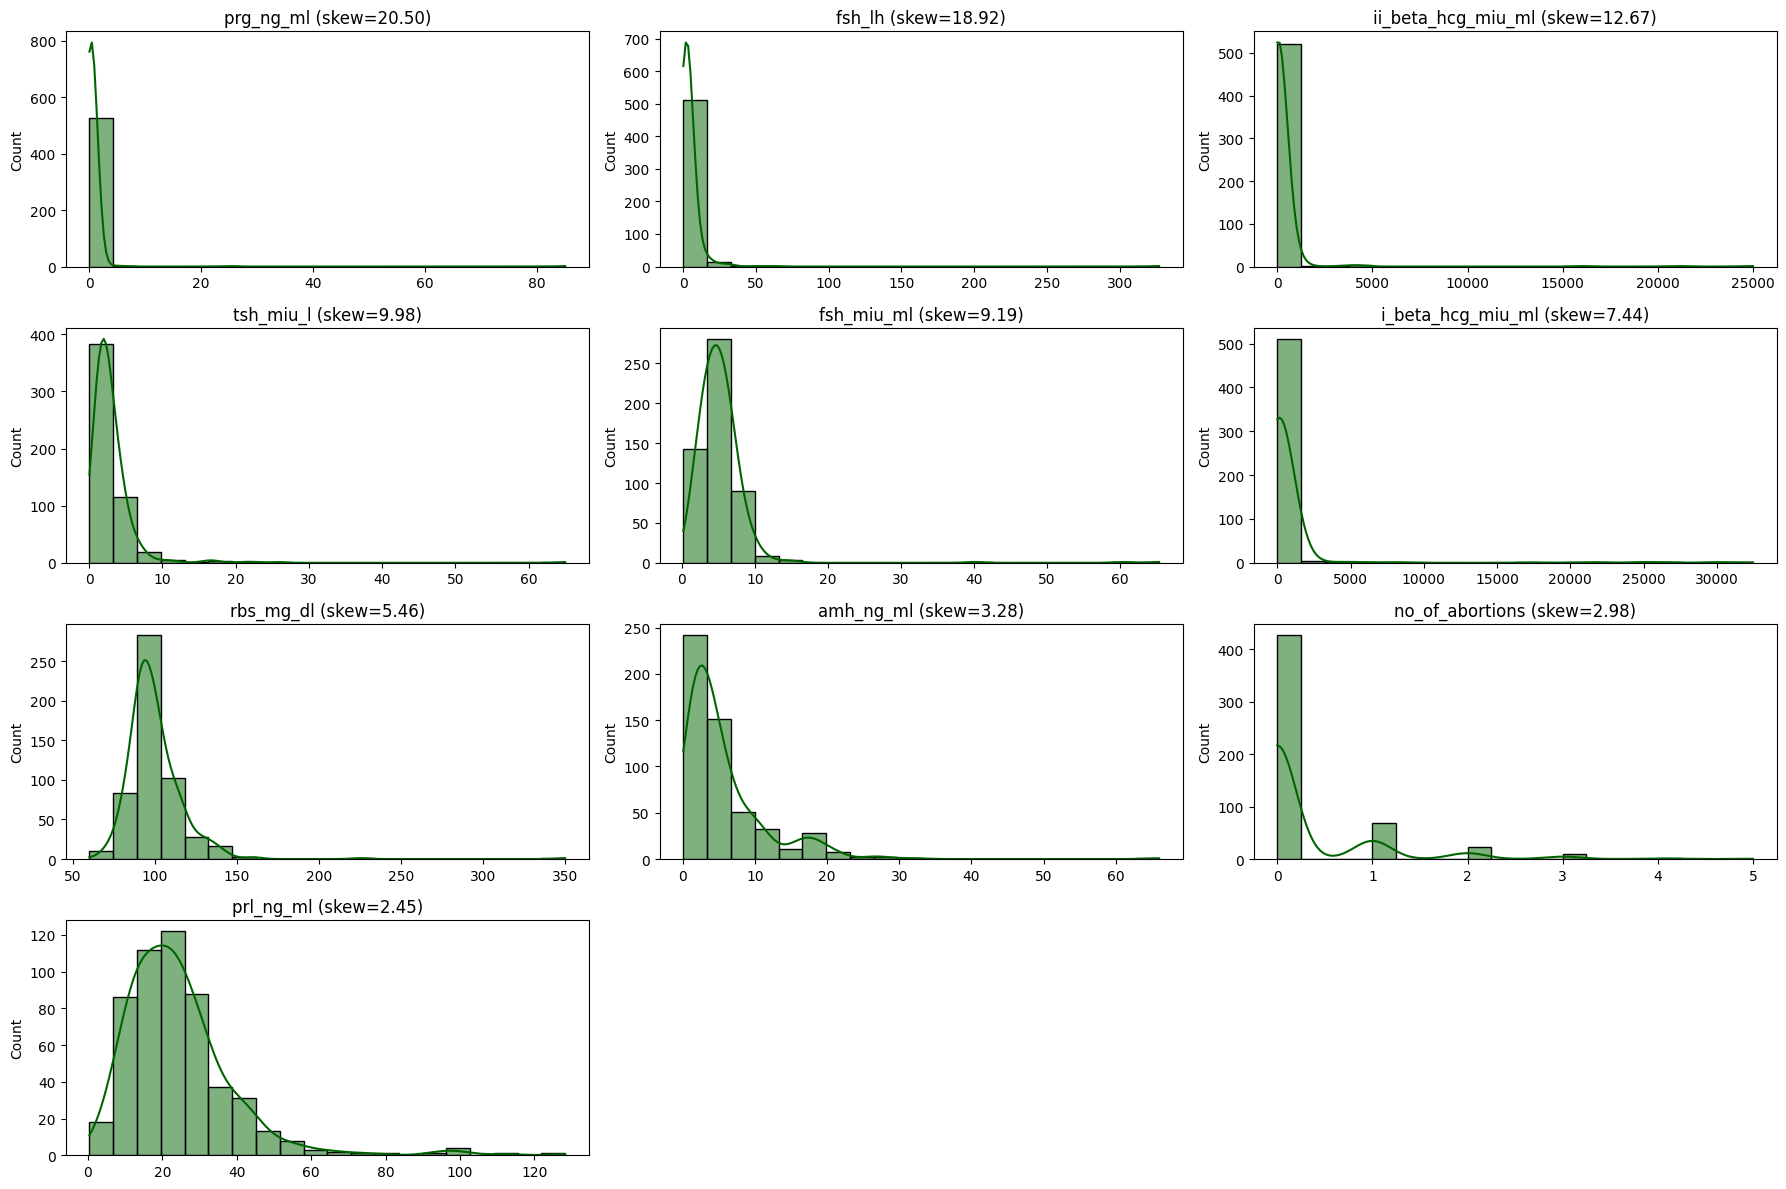

In [19]:
### skewness check
skew_table = df[plot_cols].skew().sort_values(ascending=False)
print(skew_table)

## inspect most skewed variables
top_skewed = skew_table.head(10).index.tolist()

plt.figure(figsize=(18, 12))
for i, col in enumerate(top_skewed, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color="darkgreen")
    plt.title(f"{col} (skew={df[col].skew():.2f})")
    plt.xlabel("")
plt.tight_layout()
plt.show()

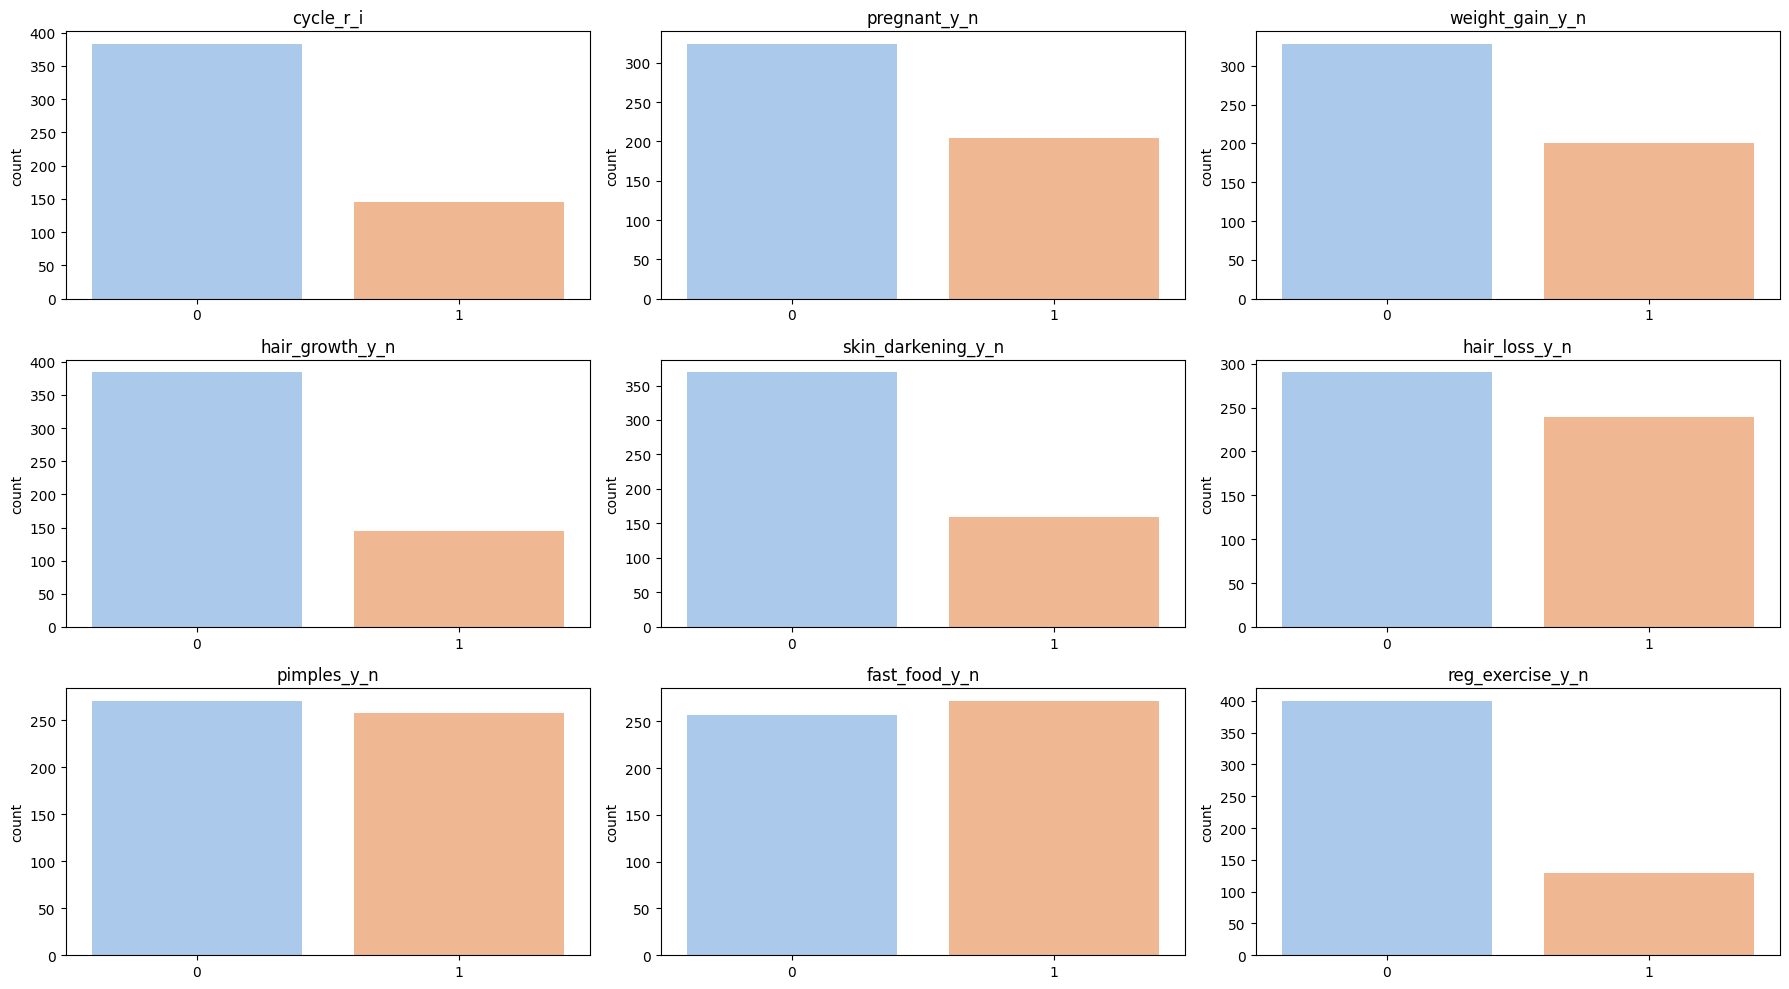

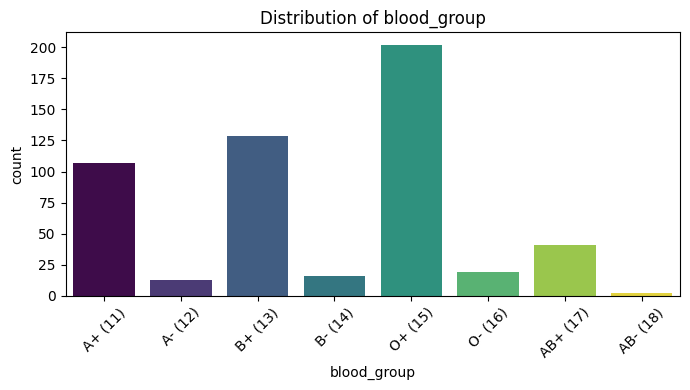

In [20]:
### binary/categorical feature counts
## binary features
bin_features = [c for c in binary_cols if c in df.columns and c != target]

plt.figure(figsize=(18, 10))
for i, col in enumerate(bin_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, palette="pastel", hue=col, legend=False)
    plt.title(col)
    plt.xlabel("")
plt.tight_layout()
plt.show()

## low-cardinality categorical variables
blood_group_map = {
    11: 'A+', 12: 'A-', 13: 'B+', 14: 'B-',
    15: 'O+', 16: 'O-', 17: 'AB+', 18: 'AB-'
}

for col in cat_cols:
    plt.figure(figsize=(7,4))
    ax = sns.countplot(data=df, x=col, palette="viridis", hue=col, legend=False)
    plt.title(f"Distribution of {col}")

    if col == 'blood_group':
        current_ticks = ax.get_xticks()
        # get numerical values from the current tick labels
        tick_values = [int(t.get_text()) for t in ax.get_xticklabels()]

        # create new labels with both the mapped string and original number
        new_labels = []
        for val in tick_values:
            if val in blood_group_map:
                new_labels.append(f"{blood_group_map[val]} ({val})")
            else:
                new_labels.append(str(val)) # fallback if value not in map

        ax.set_xticks(current_ticks) # keep original tick positions
        ax.set_xticklabels(new_labels, rotation=45)
    else:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

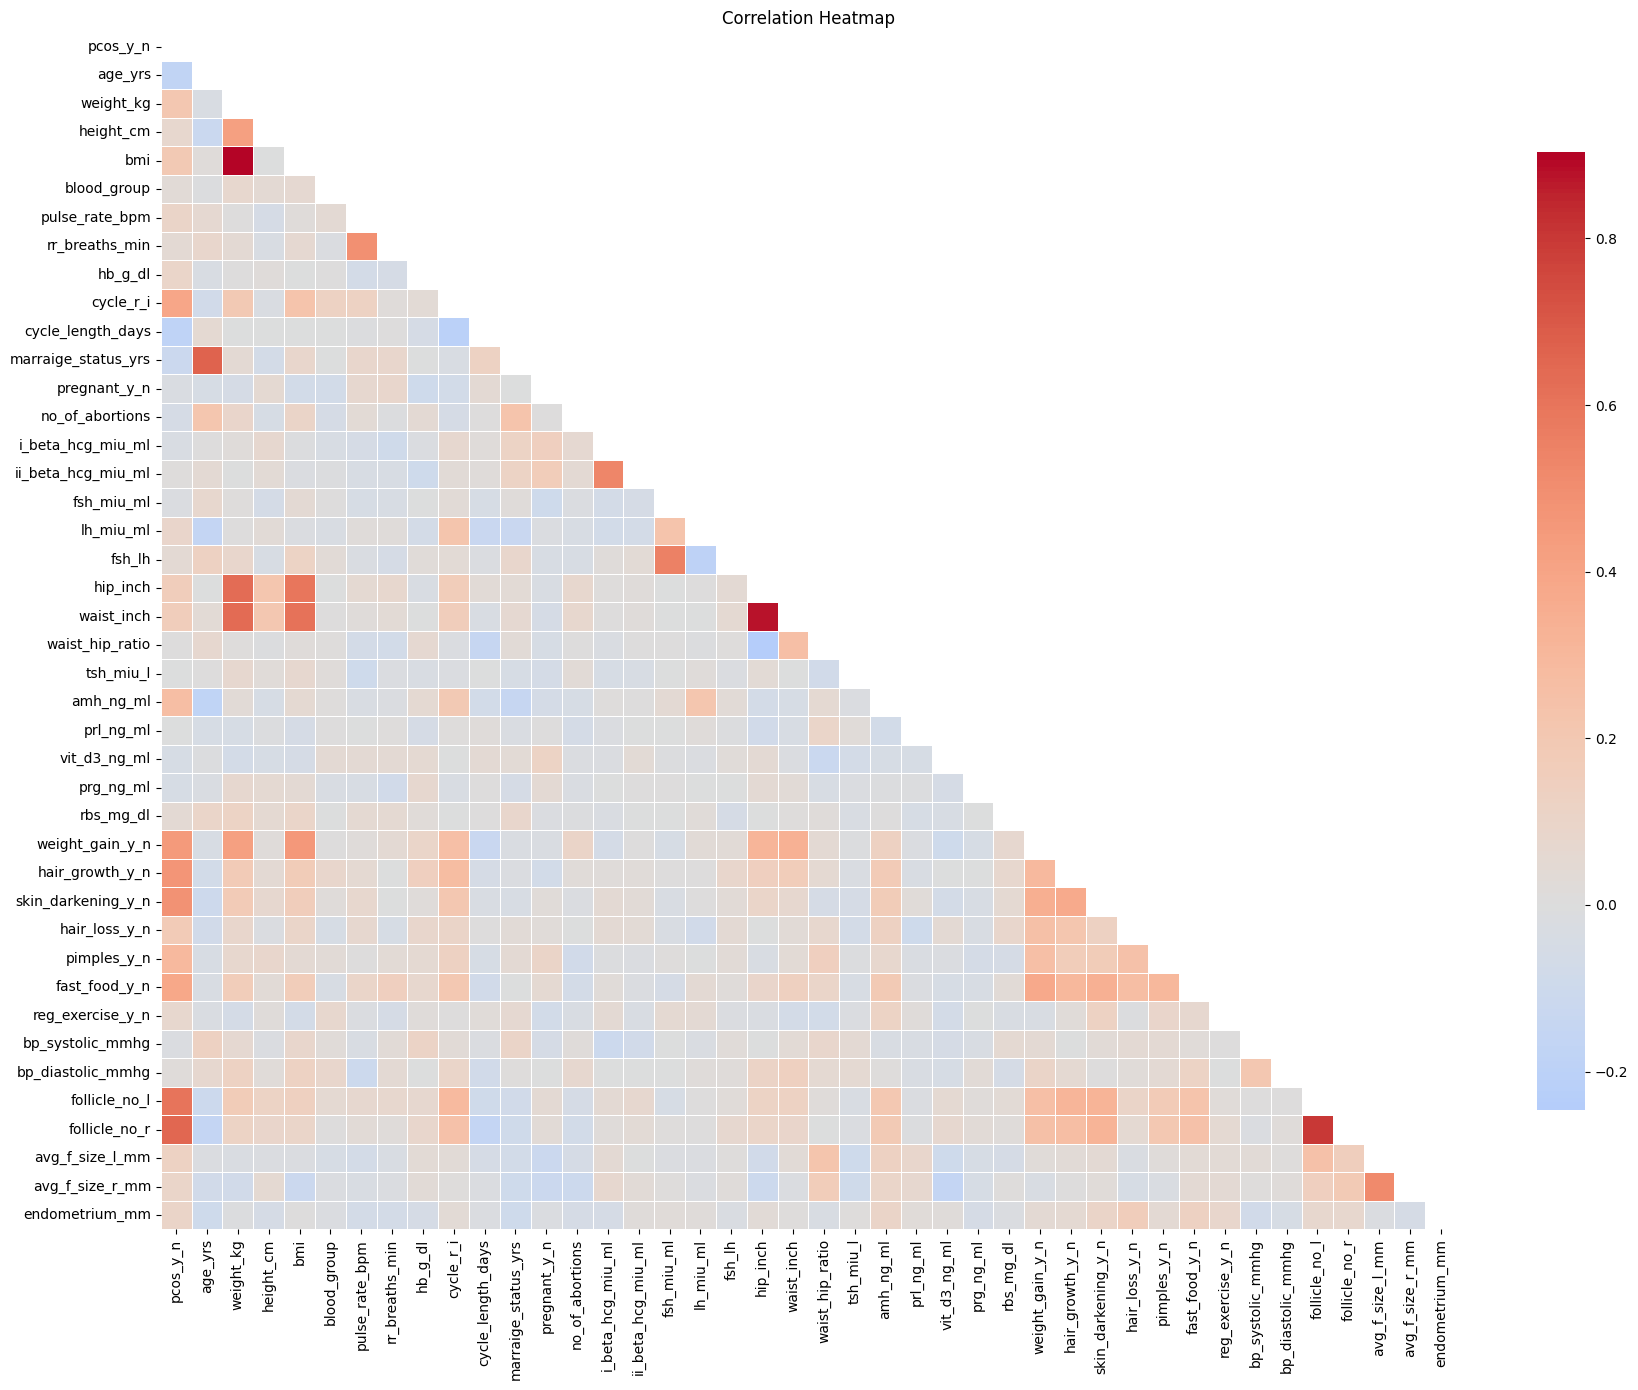

In [21]:
### correlation heatmap
plt.figure(figsize=(18, 14))
corr = df[num_eda_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

pcos_y_n               1.000000
follicle_no_r          0.647907
follicle_no_l          0.600715
skin_darkening_y_n     0.483023
hair_growth_y_n        0.469131
weight_gain_y_n        0.446030
cycle_r_i              0.392973
fast_food_y_n          0.384027
pimples_y_n            0.291562
amh_ng_ml              0.264540
weight_kg              0.209121
bmi                    0.194071
hair_loss_y_n          0.180755
hip_inch               0.159330
waist_inch             0.157774
avg_f_size_l_mm        0.125796
endometrium_mm         0.105915
pulse_rate_bpm         0.104106
hb_g_dl                0.092991
avg_f_size_r_mm        0.091917
lh_miu_ml              0.090854
height_cm              0.075717
reg_exercise_y_n       0.075716
rbs_mg_dl              0.047889
fsh_lh                 0.043603
rr_breaths_min         0.042213
blood_group            0.033102
bp_diastolic_mmhg      0.023595
ii_beta_hcg_miu_ml     0.014301
waist_hip_ratio        0.004724
prl_ng_ml             -0.000527
tsh_miu_

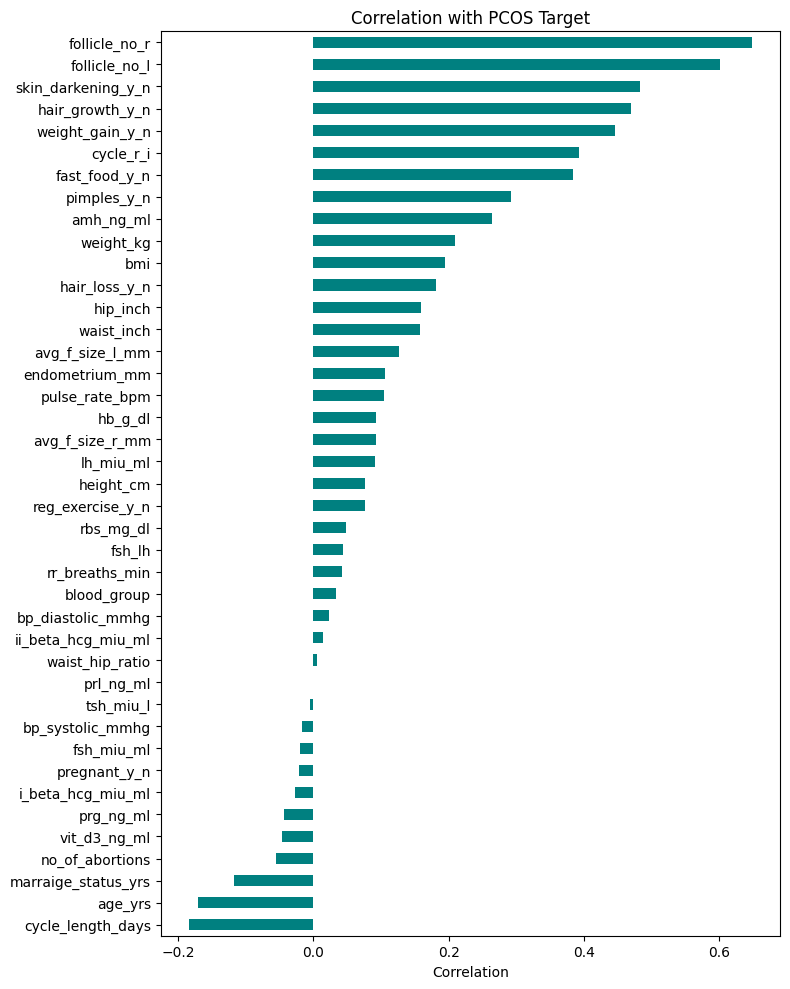

In [22]:
### correlation with target (pcos_y_n) only
target_corr = df[num_eda_cols].corr()[target].sort_values(ascending=False)
print(target_corr)

## bar plot of top positive/negative associations
plt.figure(figsize=(8,10))
target_corr.drop(target).sort_values().plot(kind="barh", color="teal")
plt.title("Correlation with PCOS Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

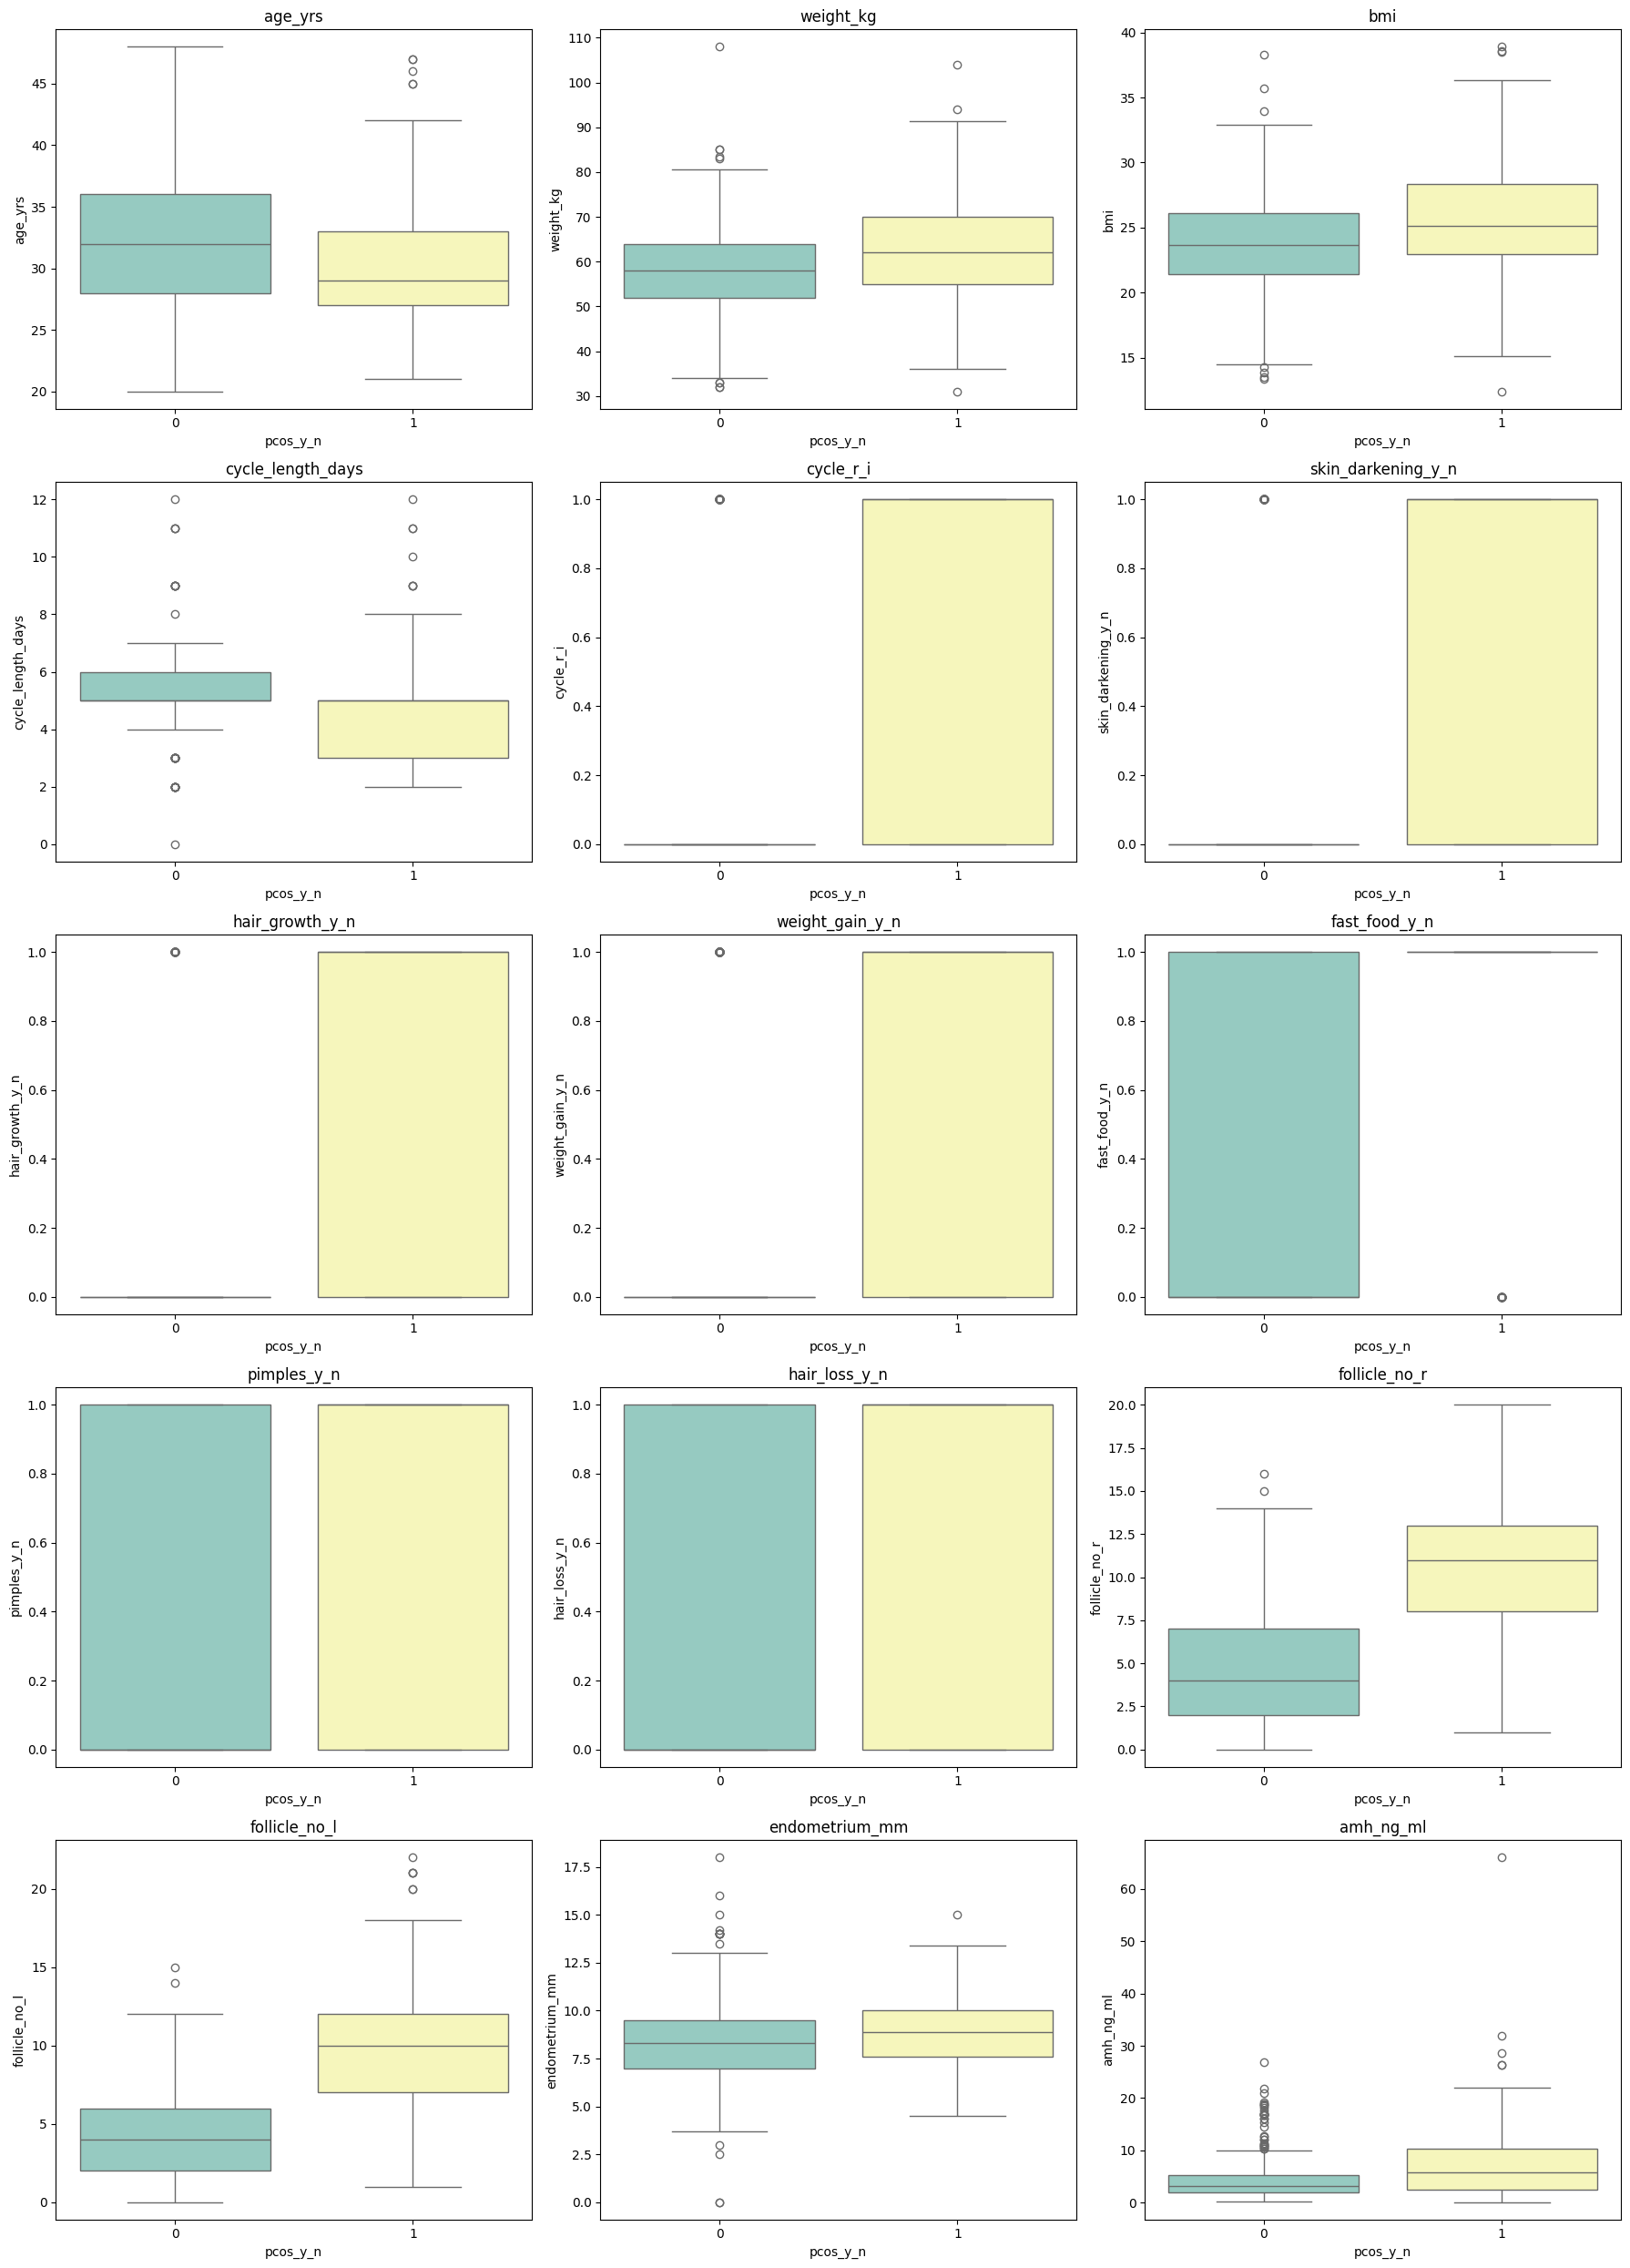

In [23]:
### feature-vs-target comparisons
important_cols = [
    "age_yrs", "weight_kg", "bmi", "cycle_length_days", "cycle_r_i",
    "skin_darkening_y_n", "hair_growth_y_n", "weight_gain_y_n",
    "fast_food_y_n", "pimples_y_n", "hair_loss_y_n", "follicle_no_r",
    "follicle_no_l", "endometrium_mm", "amh_ng_ml"
]

important_cols = [c for c in important_cols if c in df.columns]

cols = 3
nrows = math.ceil(len(important_cols) / ncols)

plt.figure(figsize=(18, 5 * nrows))
for i, col in enumerate(important_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(data=df, x=target, y=col, hue=target, palette="Set3", legend=False)
    plt.title(col)
plt.tight_layout()
plt.show()

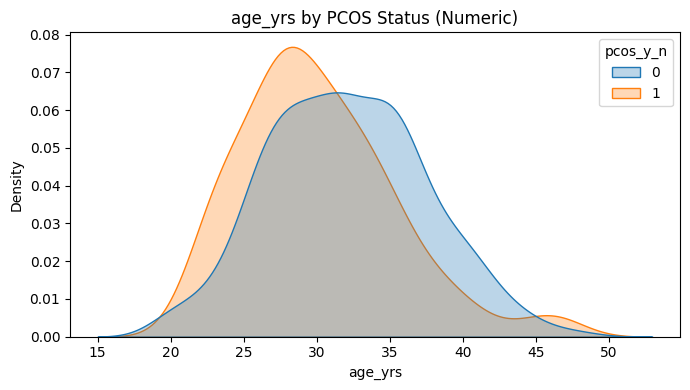

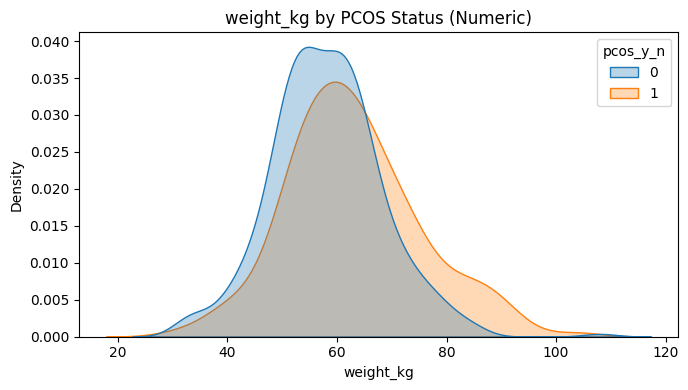

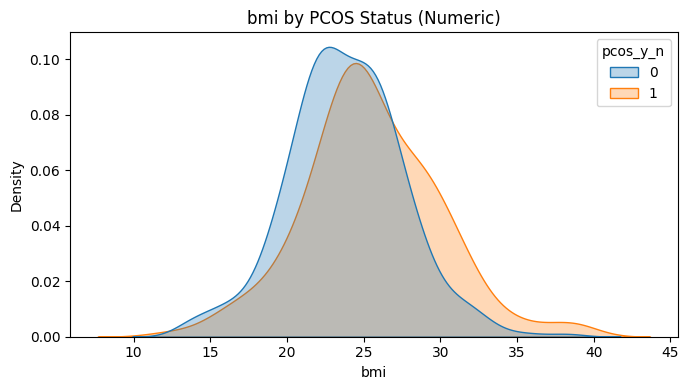

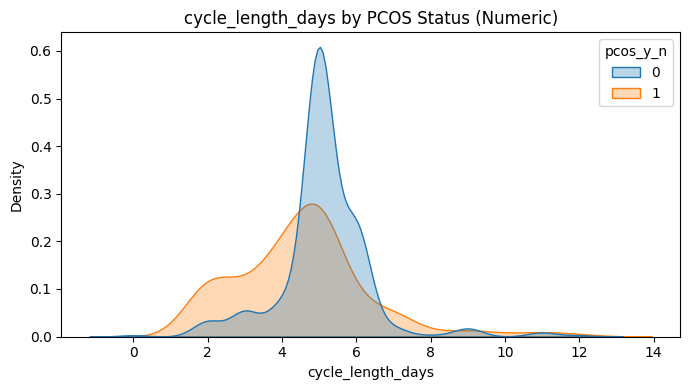

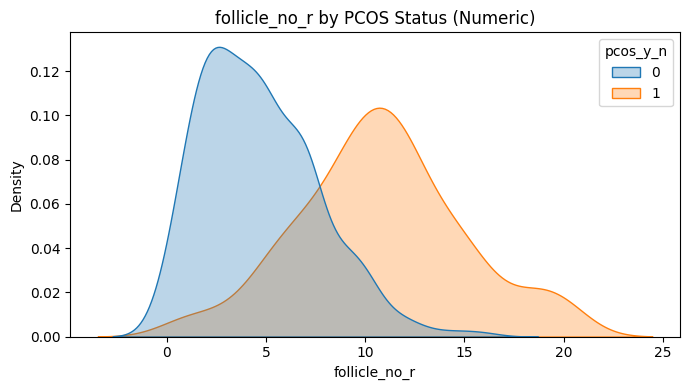

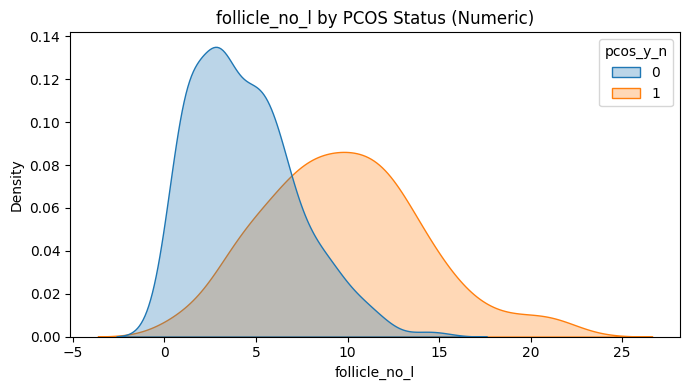

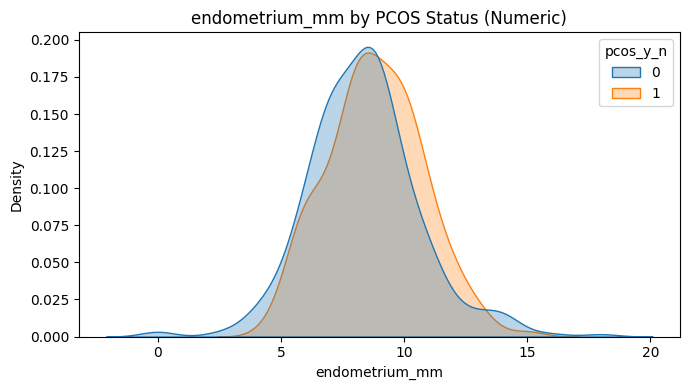

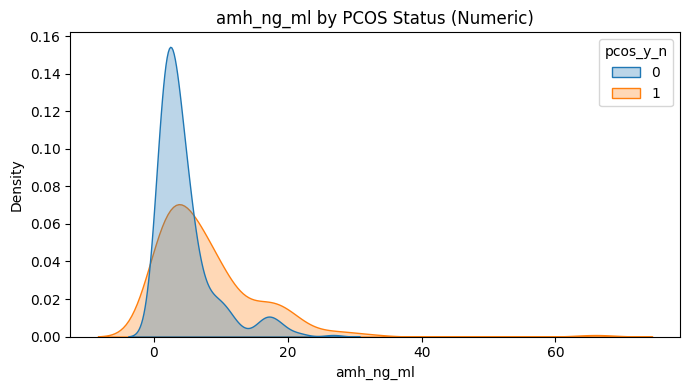

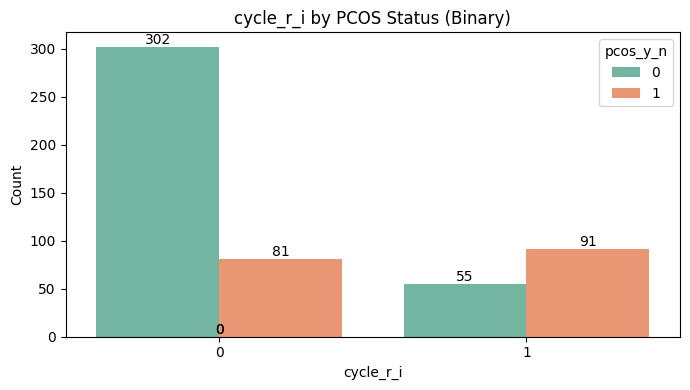

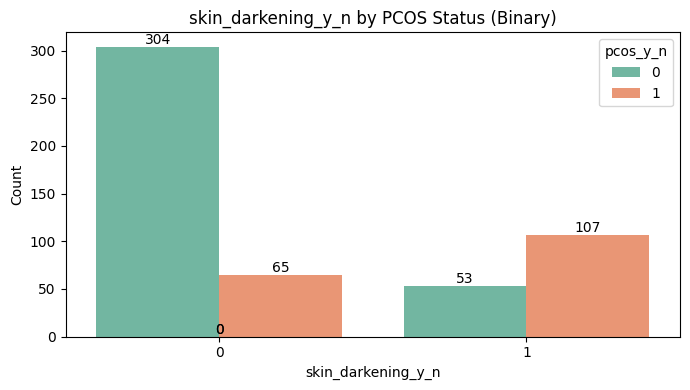

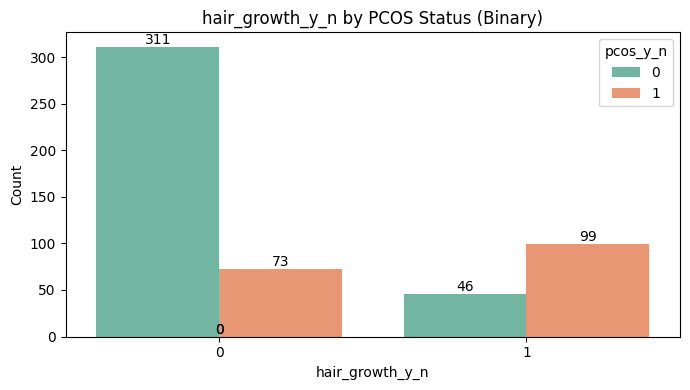

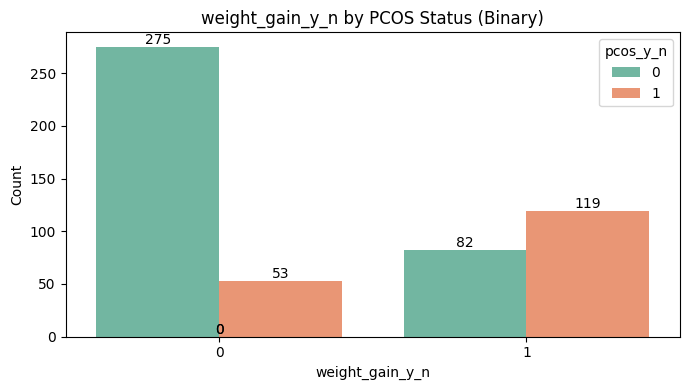

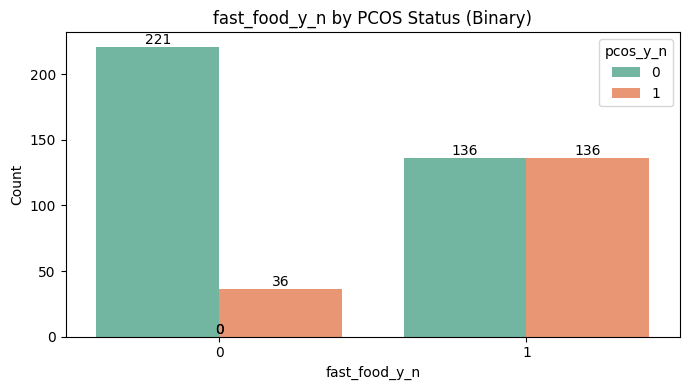

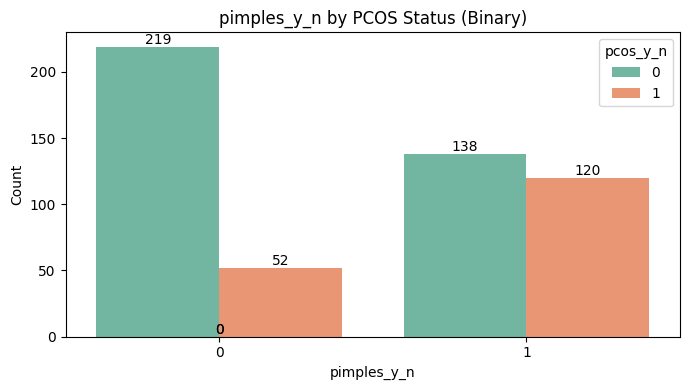

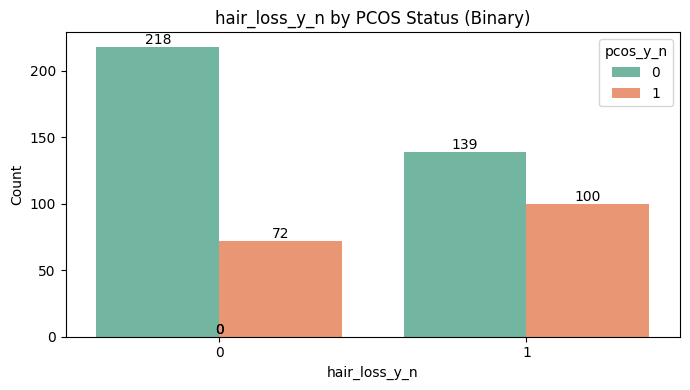

In [24]:
### compare feature distribution by PCOS status
import matplotlib.pyplot as plt
import seaborn as sns

## separate important_cols into numeric and binary
numeric_important_cols = [col for col in important_cols if col in num_eda_cols and col not in binary_cols]
binary_important_cols = [col for col in important_cols if col in binary_cols]

## plot for numeric columns using kdeplot
for col in numeric_important_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue=target, common_norm=False, fill=True, alpha=0.3)
    plt.title(f"{col} by PCOS Status (Numeric)")
    plt.tight_layout()
    plt.show()

## plot for binary columns using countplot
for col in binary_important_cols:
    plt.figure(figsize=(7,4))
    ax = sns.countplot(data=df, x=col, hue=target, palette="Set2")
    plt.title(f"{col} by PCOS Status (Binary)")
    plt.xlabel(col)
    plt.ylabel("Count")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')
    plt.tight_layout()
    plt.show()

# Model Training (Random Forest and XGBoost)
Reasons for models chosen:
*   Random Forest is a good baseline as it is easier to train and interpret.
*   XGBoost usually captures subtle patterns better.


This is the training workflow:
1.   Import libraries
2.   Load dataset
3.   Check target distribution
4.   Remove ID-like columns
5.   Split features and target
6.   Train-test split with stratification
7.   Compute class imbalance weight (XGBoost only)
8.   Train the Random Forest/XGBoost model
9.   Threshold tuning
10.  Make predictions
11.  Evaluate the model (accuracy, ROC-AUC, confusion matrix, recall, F1-score)
12.  Plot feature importance

Recall for class 1:
*   Formula = True Positives / (True Positives + False Negatives)
*   Definition: Among the people who actually have PCOS (`1`), how many the model correctly identifies as `1`. It is the proportion of true PCOS cases that the model successfully catches.
*   It is important as missing a positive case is costly. If recall for class 1 is low, the model may be missing many PCOS cases even if overall accuracy looks fine. In medical prediction, that can be a problem because a false negative means the model predicts 0 when the person is actually 1.

Target class distribution:
*   The classes for `pcos_y_n` are imbalanced, class 0 has 357 samples (67.5%) and class 1 has 172 samples (32.5%).
*   Random Forest can pay more attention to the minority class if we use stratified splitting (`stratify=y`) and `class_weight="balanced"` in building the model.
*   XGBoost can work well with this imbalance if we use stratified splitting (`stratify=y`) and tune the positive-class weight (`scale_pos_weight`).

## Predictive Risk Model and Doctor Dashboard
This section consists of model training (Random Forest and XGBoost) to build a risk predictive model, to aid doctors in PCOS diagnosis.

By comparing the model evaluation metrics, we decided to use XGBoost as the model for risk prediction.
*   Higher recall for class 1
*   Less False Negatives, less PCOS cases will be missed out

The predictive risk framework is then built.



### Doctor: Model Training (Random Forest)

Class counts:
pcos_y_n
0    357
1    172
Name: count, dtype: int64

Class proportions:
pcos_y_n
0    0.674858
1    0.325142
Name: proportion, dtype: float64

Training set class counts:
pcos_y_n
0    285
1    138
Name: count, dtype: int64

Test set class counts:
pcos_y_n
0    72
1    34
Name: count, dtype: int64

Random Forest training complete.

Random Forest evaluation:
Accuracy: 0.9339622641509434
ROC-AUC: 0.9650735294117647
Recall for class 1: 0.8235294117647058
Confusion Matrix:
 [[71  1]
 [ 6 28]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.82      0.89        34

    accuracy                           0.93       106
   macro avg       0.94      0.90      0.92       106
weighted avg       0.94      0.93      0.93       106



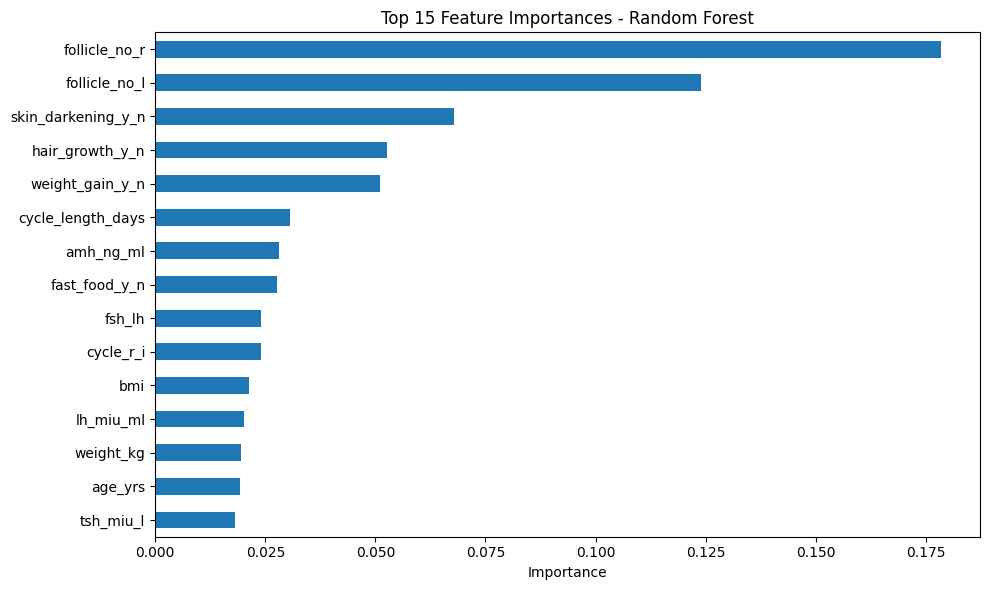

In [25]:
### import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split  # for splitting dataset into training and testing sets
from sklearn.metrics import (    # for evaluating the model
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score
)
from sklearn.ensemble import RandomForestClassifier  # random forest model
import matplotlib.pyplot as plt  # for plotting feature importance

### load dataset
df = pd.read_csv("cleaned_pcos_dataset.csv")

### check target class distribution
print("Class counts:")
print(df["pcos_y_n"].value_counts())

print("\nClass proportions:")
print(df["pcos_y_n"].value_counts(normalize=True))

### remove id-like columns (do not help with prediction)
df = df.drop(columns=["sl_no", "patient_file_no"], errors="ignore")

### split features and target
X = df.drop(columns=["pcos_y_n"])  # X = input features
y = df["pcos_y_n"]                 # y = target

### train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% test set
    random_state=42,  # ensures reproducibility
    stratify=y        # keeps class ratio similar in both train and test sets, since classes are imbalanced
)

print("\nTraining set class counts:")
print(y_train.value_counts())

print("\nTest set class counts:")
print(y_test.value_counts())

### random forest model
## build model
doc_rf_model = RandomForestClassifier(
    n_estimators=300,         # no. of trees in the forest
    max_depth=None,           # allow trees to grow fully unless split rules stop them
    min_samples_split=2,      # minimum samples needed to split a node
    min_samples_leaf=1,       # minimum samples required at a leaf node
    class_weight="balanced",  # helps model pay more attention to the minority class
    random_state=42,          # reproducibility
    n_jobs=-1                 # use all available CPU cores
)

## train model
doc_rf_model.fit(X_train, y_train)
print("\nRandom Forest training complete.")

### predict
doc_y_pred_rf = doc_rf_model.predict(X_test)
doc_y_prob_rf = doc_rf_model.predict_proba(X_test)[:, 1]

### evaluate model
print("\nRandom Forest evaluation:")
print("Accuracy:", accuracy_score(y_test, doc_y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, doc_y_prob_rf))
print("Recall for class 1:", recall_score(y_test, doc_y_pred_rf, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, doc_y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, doc_y_pred_rf))

### plot feature importance
## convert feature importances into a pandas series
importances = pd.Series(doc_rf_model.feature_importances_, index=X.columns)  # random forest gives feature importance directly
top_features = importances.sort_values(ascending=False).head(15)  # top 15 most important features

## plot features
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Doctor: Model Training (XGBoost)

Class counts:
pcos_y_n
0    357
1    172
Name: count, dtype: int64

Class proportions:
pcos_y_n
0    0.674858
1    0.325142
Name: proportion, dtype: float64

Training set class counts:
pcos_y_n
0    285
1    138
Name: count, dtype: int64

Test set class counts:
pcos_y_n
0    72
1    34
Name: count, dtype: int64
scale_pos_weight: 2.0652173913043477

XGBoost training complete.

XGBoost evaluation:

Accuracy: 0.9339622641509434
ROC-AUC: 0.9497549019607843
Recall for class 1: 0.8529411764705882
Confusion Matrix:
 [[70  2]
 [ 5 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.94      0.85      0.89        34

    accuracy                           0.93       106
   macro avg       0.93      0.91      0.92       106
weighted avg       0.93      0.93      0.93       106



<Figure size 1000x600 with 0 Axes>

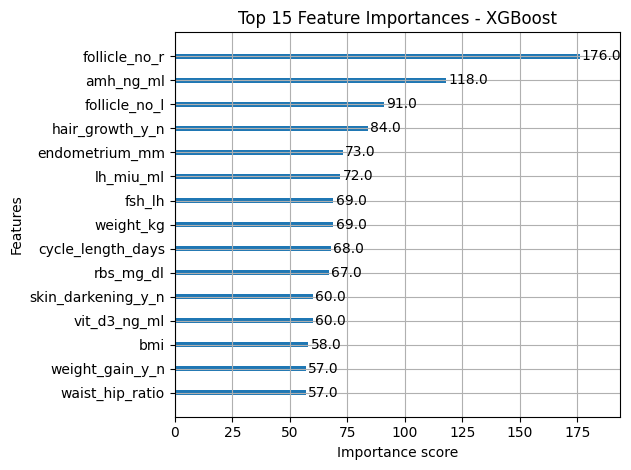

In [26]:
### import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split    # for splitting dataset into training and testing sets
from sklearn.metrics import (    # for evaluating the model
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score
)
from xgboost import XGBClassifier, plot_importance  # for XGBoost model
import matplotlib.pyplot as plt  # for plotting feature importance

### load dataset
df = pd.read_csv("cleaned_pcos_dataset.csv")

### check target class distribution
print("Class counts:")
print(df["pcos_y_n"].value_counts())

print("\nClass proportions:")
print(df["pcos_y_n"].value_counts(normalize=True))

### remove id-like columns (do not help with prediction)
df = df.drop(columns=["sl_no", "patient_file_no"], errors="ignore")

### split features and target
X = df.drop(columns=["pcos_y_n"])  # X = input features
y = df["pcos_y_n"]                 # y = target

### train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% test set
    random_state=42,  # ensures reproducibility
    stratify=y        # keeps class ratio similar in both train and test sets, since classes are imbalanced
)

print("\nTraining set class counts:")
print(y_train.value_counts())

print("\nTest set class counts:")
print(y_test.value_counts())

### compute class imbalance weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

### xgboost model
## build model
doc_xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

## train model
doc_xgb_model.fit(X_train, y_train)
print("\nXGBoost training complete.")

### predict
doc_y_pred_xgb = doc_xgb_model.predict(X_test)
doc_y_prob_xgb = doc_xgb_model.predict_proba(X_test)[:, 1]

### evaluate model
print("\nXGBoost evaluation:")
print("\nAccuracy:", accuracy_score(y_test, doc_y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, doc_y_prob_xgb))
print("Recall for class 1:", recall_score(y_test, doc_y_pred_xgb, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, doc_y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, doc_y_pred_xgb))

### plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(doc_xgb_model, max_num_features=15)
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

### Doctor: Predictive Risk Model

In [27]:
### risk assessment
def get_risk_band(prob):  # probability assignment to different risk bands
    if prob < 0.20:
        return "Low"
    elif prob < 0.50:
        return "Moderate"
    elif prob < 0.80:
        return "High"
    else:
        return "Very High"

def get_risk_message(prob):  # message sent for each risk band
    if prob < 0.20:
        return "Low estimated PCOS risk based on the risk assessment model."
    elif prob < 0.50:
        return "Moderate estimated PCOS risk based on the risk assessment model."
    elif prob < 0.80:
        return "High estimated PCOS risk based on the risk assessment model."
    else:
        return "Very high estimated PCOS risk based on the risk assessment model."

## results
risk_results = pd.DataFrame({
    "actual_class": y_test.values,
    "predicted_class": doc_y_pred_xgb,
    "probability": doc_y_prob_xgb
})

risk_results["pcos_risk_percentage"] = (risk_results["probability"] * 100).round(2)
risk_results["risk_band"] = risk_results["probability"].apply(get_risk_band)
risk_results["result"] = risk_results["probability"].apply(get_risk_message)

print("\nPCOS risk assessment results (first 10 rows):")
print(risk_results.head(10))

### save results
risk_results.to_csv("xgboost_doctor_risk_assessment_results.csv", index=False)
print("\nSaved to xgboost_doctor_risk_assessment_results.csv")


PCOS risk assessment results (first 10 rows):
   actual_class  predicted_class  probability  pcos_risk_percentage  \
0             0                0     0.069910              6.990000   
1             0                0     0.015701              1.570000   
2             0                0     0.041120              4.110000   
3             0                0     0.012227              1.220000   
4             0                0     0.004640              0.460000   
5             0                0     0.004160              0.420000   
6             1                0     0.291842             29.180000   
7             0                0     0.004882              0.490000   
8             1                1     0.939515             93.949997   
9             1                0     0.003824              0.380000   

   risk_band                                             result  
0        Low  Low estimated PCOS risk based on the risk asse...  
1        Low  Low estimated PCOS risk b

## General Patient/User Assessment Form
This section consists of model training (Random Forest and XGBoost) to build a general risk assessment model, to allow general women to gauge if they may possibly have PCOS.

Only self-reportable, symptomatic and phenotypic features are used in this model as general women users usually do not have clinical data and can only determine based on what they observe.

By comparing the model evaluation metrics, we decided to use XGBoost as the model for risk assessment.
*   Higher recall for class 1
*   Less False Negatives, less PCOS cases will be missed out

The risk assessment framework is then built.

### Patient: Model Training (Random Forest)

Class counts:
pcos_y_n
0    357
1    172
Name: count, dtype: int64

Class proportions:
pcos_y_n
0    0.674858
1    0.325142
Name: proportion, dtype: float64
Features used: ['age_yrs', 'weight_kg', 'height_cm', 'bmi', 'blood_group', 'cycle_r_i', 'cycle_length_days', 'marraige_status_yrs', 'pregnant_y_n', 'no_of_abortions', 'hip_inch', 'waist_inch', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n']
Shape: (529, 19)

Training set class counts:
pcos_y_n
0    285
1    138
Name: count, dtype: int64

Test set class counts:
pcos_y_n
0    72
1    34
Name: count, dtype: int64

Random Forest training complete.

Random Forest evaluation:
Accuracy: 0.8301886792452831
ROC-AUC: 0.8729575163398693
Recall for class 1: 0.6764705882352942
Confusion Matrix:
 [[65  7]
 [11 23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88        72
           1       

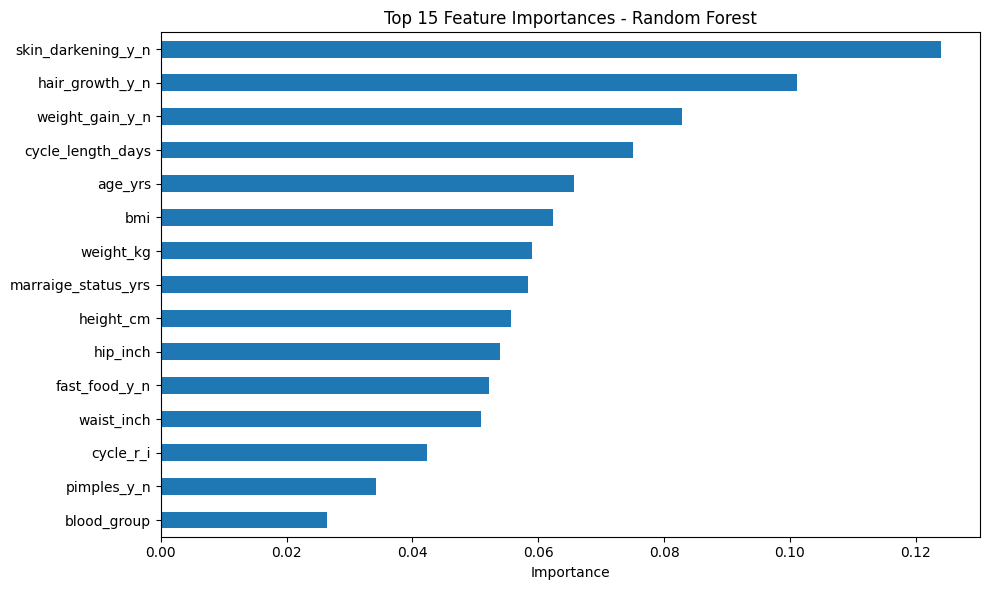

In [28]:
### import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split  # for splitting dataset into training and testing sets
from sklearn.metrics import (    # for evaluating the model
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score
)
from sklearn.ensemble import RandomForestClassifier  # random forest model
import matplotlib.pyplot as plt  # for plotting feature importance

### load dataset
df = pd.read_csv("cleaned_pcos_dataset.csv")

### define target and self-reportable features only
target_col = "pcos_y_n"

user_features = [
    "age_yrs", "weight_kg", "height_cm", "bmi", "blood_group", "cycle_r_i",
    "cycle_length_days", "marraige_status_yrs", "pregnant_y_n", "no_of_abortions",
    "hip_inch", "waist_inch", "weight_gain_y_n", "hair_growth_y_n", "skin_darkening_y_n",
    "hair_loss_y_n", "pimples_y_n", "fast_food_y_n", "reg_exercise_y_n"
]

## keep only columns that actually exist
user_features = [c for c in user_features if c in df.columns]

## drop missing rows for selected fields
model_df = df[user_features + [target_col]].copy()
model_df = model_df.dropna()

### check target class distribution
print("Class counts:")
print(df["pcos_y_n"].value_counts())

print("\nClass proportions:")
print(df["pcos_y_n"].value_counts(normalize=True))

### split features and target
X = model_df[user_features]
y = model_df[target_col].astype(int)

print("Features used:", user_features)
print("Shape:", X.shape)

### train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% test set
    random_state=42,  # ensures reproducibility
    stratify=y        # keeps class ratio similar in both train and test sets, since classes are imbalanced
)

print("\nTraining set class counts:")
print(y_train.value_counts())

print("\nTest set class counts:")
print(y_test.value_counts())

### random forest model
## build model
pat_rf_model = RandomForestClassifier(
    n_estimators=300,         # no. of trees in the forest
    max_depth=None,           # allow trees to grow fully unless split rules stop them
    min_samples_split=2,      # minimum samples needed to split a node
    min_samples_leaf=1,       # minimum samples required at a leaf node
    class_weight="balanced",  # helps model pay more attention to the minority class
    random_state=42,          # reproducibility
    n_jobs=-1                 # use all available CPU cores
)

## train model
pat_rf_model.fit(X_train, y_train)
print("\nRandom Forest training complete.")

### predict
pat_y_pred_rf = pat_rf_model.predict(X_test)
pat_y_prob_rf = pat_rf_model.predict_proba(X_test)[:, 1]

### evaluate model
print("\nRandom Forest evaluation:")
print("Accuracy:", accuracy_score(y_test, pat_y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, pat_y_prob_rf))
print("Recall for class 1:", recall_score(y_test, pat_y_pred_rf, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, pat_y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, pat_y_pred_rf))

### plot feature importance
## convert feature importances into a pandas series
importances = pd.Series(pat_rf_model.feature_importances_, index=X.columns)  # random forest gives feature importance directly
top_features = importances.sort_values(ascending=False).head(15)  # top 15 most important features

## plot features
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Patient: Model Training (XGBoost)

Class counts:
pcos_y_n
0    357
1    172
Name: count, dtype: int64

Class proportions:
pcos_y_n
0    0.674858
1    0.325142
Name: proportion, dtype: float64
Features used: ['age_yrs', 'weight_kg', 'height_cm', 'bmi', 'blood_group', 'cycle_r_i', 'cycle_length_days', 'marraige_status_yrs', 'pregnant_y_n', 'no_of_abortions', 'hip_inch', 'waist_inch', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'reg_exercise_y_n']
Shape: (529, 19)

Training set class counts:
pcos_y_n
0    285
1    138
Name: count, dtype: int64

Test set class counts:
pcos_y_n
0    72
1    34
Name: count, dtype: int64
scale_pos_weight: 2.0652173913043477

XGBoost training complete.

XGBoost evaluation:

Accuracy: 0.8301886792452831
ROC-AUC: 0.8558006535947712
Recall for class 1: 0.7352941176470589
Confusion Matrix:
 [[63  9]
 [ 9 25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88    

<Figure size 1000x600 with 0 Axes>

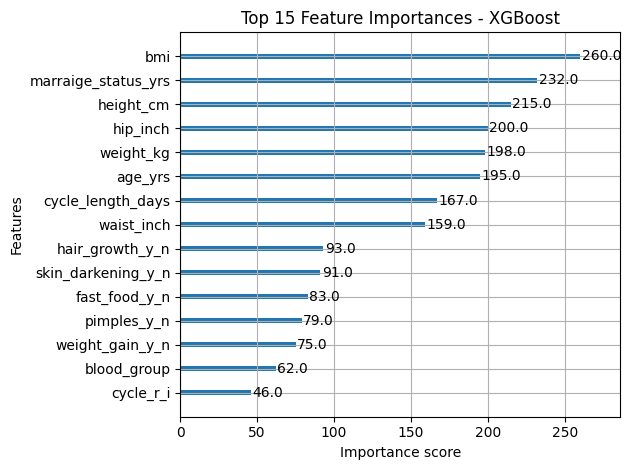

In [31]:
### import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split    # for splitting dataset into training and testing sets
from sklearn.metrics import (    # for evaluating the model
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score
)
from xgboost import XGBClassifier, plot_importance  # for XGBoost model
import matplotlib.pyplot as plt  # for plotting feature importance

### load dataset
df = pd.read_csv("cleaned_pcos_dataset.csv")

### define target and self-reportable features only
target_col = "pcos_y_n"

user_features = [
    "age_yrs", "weight_kg", "height_cm", "bmi", "blood_group", "cycle_r_i",
    "cycle_length_days", "marraige_status_yrs", "pregnant_y_n", "no_of_abortions",
    "hip_inch", "waist_inch", "weight_gain_y_n", "hair_growth_y_n", "skin_darkening_y_n",
    "hair_loss_y_n", "pimples_y_n", "fast_food_y_n", "reg_exercise_y_n"
]

## keep only columns that actually exist
user_features = [c for c in user_features if c in df.columns]

## drop missing rows for selected fields
model_df = df[user_features + [target_col]].copy()
model_df = model_df.dropna()

### check target class distribution
print("Class counts:")
print(df["pcos_y_n"].value_counts())

print("\nClass proportions:")
print(df["pcos_y_n"].value_counts(normalize=True))

### split features and target
X = model_df[user_features]
y = model_df[target_col].astype(int)

print("Features used:", user_features)
print("Shape:", X.shape)

### train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% test set
    random_state=42,  # ensures reproducibility
    stratify=y        # keeps class ratio similar in both train and test sets, since classes are imbalanced
)

print("\nTraining set class counts:")
print(y_train.value_counts())

print("\nTest set class counts:")
print(y_test.value_counts())

### compute class imbalance weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

### xgboost model
## build model
pat_xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

## train model
pat_xgb_model.fit(X_train, y_train)
print("\nXGBoost training complete.")

### predict
pat_y_pred_xgb = pat_xgb_model.predict(X_test)
pat_y_prob_xgb = pat_xgb_model.predict_proba(X_test)[:, 1]

### evaluate model
print("\nXGBoost evaluation:")
print("\nAccuracy:", accuracy_score(y_test, pat_y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, pat_y_prob_xgb))
print("Recall for class 1:", recall_score(y_test, pat_y_pred_xgb, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, pat_y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, pat_y_pred_xgb))

### plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(pat_xgb_model, max_num_features=15)
plt.title("Top 15 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

### Patient: General Assessment Form

In [33]:
### risk assessment
def get_risk_band(prob):  # probability assignment to different risk bands
    if prob < 0.20:
        return "Low"
    elif prob < 0.50:
        return "Moderate"
    elif prob < 0.80:
        return "High"
    else:
        return "Very High"

def get_risk_message(prob):  # message sent for each risk band
    if prob < 0.20:
        return "Low estimated PCOS risk. Continue routine monitoring and discuss symptoms with a clinician if needed. Note: This is a risk estimate, not a diagnosis."
    elif prob < 0.50:
        return "Moderate estimated PCOS risk. Consider a clinical review if symptoms such as irregular cycles, acne, or weight changes are present. Note: This is a risk estimate, not a diagnosis."
    elif prob < 0.80:
        return "High estimated PCOS risk. A clinical evaluation is recommended. Note: This is a risk estimate, not a diagnosis."
    else:
        return "Very high estimated PCOS risk. Please arrange prompt medical follow-up for formal assessment. Note: This is a risk estimate, not a diagnosis."

def should_see_doctor(prob, predicted_class):  # determine if user should see the doctor
    return (prob >= 0.50) or (predicted_class == 1)

## results
risk_results = pd.DataFrame({
    "actual_class": y_test.values,
    "predicted_class": pat_y_pred_xgb,
    "probability": pat_y_prob_xgb
})

risk_results["pcos_risk_percentage"] = (risk_results["probability"] * 100).round(2)
risk_results["risk_band"] = risk_results["probability"].apply(get_risk_band)
risk_results["result"] = risk_results["probability"].apply(get_risk_message)
risk_results["should_see_doctor"] = risk_results.apply(
    lambda row: should_see_doctor(row["probability"], row["predicted_class"]),
    axis=1
)

print("\nPCOS risk assessment results (first 10 rows):")
print(risk_results.head(10))

### save results
risk_results.to_csv("xgboost_patient_risk_assessment_results.csv", index=False)
print("\nSaved to xgboost_patient_risk_assessment_results.csv")


PCOS risk assessment results (first 10 rows):
   actual_class  predicted_class  probability  pcos_risk_percentage  \
0             0                0     0.169779             16.980000   
1             0                0     0.018057              1.810000   
2             0                0     0.351906             35.189999   
3             0                0     0.050059              5.010000   
4             0                0     0.164573             16.459999   
5             0                0     0.083088              8.310000   
6             1                0     0.036834              3.680000   
7             0                0     0.082778              8.280000   
8             1                1     0.843454             84.349998   
9             1                0     0.060369              6.040000   

   risk_band                                             result  \
0        Low  Low estimated PCOS risk. Continue routine moni...   
1        Low  Low estimated PCOS risk